# Periodic Branch Simulation Benchmark

This notebook stress-tests the current MALCA periodic branch: candidates that have already been routed to the periodic branch are scored with `phase_template_baseline`, so one-off dimming events should be detected in residuals relative to the phase-folded periodic baseline.

The simulation deliberately avoids idealized toy curves. Each light curve includes a non-perfect periodic baseline, seasonal gaps, heterogeneous cadence, multiple cameras, optional G/V band offsets, camera zero-point offsets, season-to-season zero-point drift, amplitude modulation, phase wander, slow trends, quasi-correlated residual structure, heteroscedastic errors, and occasional outliers. One-off dips are injected at small to medium amplitudes relative to the periodic baseline.

Default run size is `N_TRIALS = 120000`, with about 90% injected dips, so the benchmark includes roughly 108000 one-off dip cases by default. Results are cached under `output/diagnostics/periodic_branch_simulation_benchmark/<RUN_TAG>/`.

The default modes are:

- `phase_template_true_period`: isolates phase-template behavior when the selected period is correct.
- `phase_template_1pct_period_error`: approximates a mildly imperfect pre-gate selected period.
- `phase_template_5pct_period_error`: stress-tests selected-period quality.
- `gp_masked_control`: compares against the masked per-camera GP baseline used by the stochastic branch.

Optional alias modes are available in the helper module if you want to add half-period or double-period stress tests.

In [1]:
from __future__ import annotations

from pathlib import Path
import os
import sys
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Make the notebook robust whether launched from repo root or notebook subfolders.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "malca").is_dir():
        REPO_ROOT = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate repo root containing the malca package")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from malca.evaluation.periodic_branch_simulation_benchmark import (
    DEFAULT_MODE_NAMES,
    PERIODIC_BRANCH_MODE_SPECS,
    PeriodicBranchSimConfig,
    load_periodic_branch_simulation_benchmark,
    metric_heatmap,
    plot_metric_distributions,
    plot_overall_metrics,
    plot_trial_diagnostic,
    run_periodic_branch_simulation_benchmark,
    select_example_trials,
)

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 220)
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 180})

REPO_ROOT

/home/calder/miniforge3/envs/malca/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/home/calder/code/malca')

## Configuration

Use environment variables to change the run without editing the notebook:

- `MALCA_PERIODIC_BRANCH_SMOKE=1` runs a small smoke grid.
- `MALCA_PERIODIC_BRANCH_N_TRIALS=120000` changes sample size.
- `MALCA_PERIODIC_BRANCH_WORKERS=8` changes parallelism.
- `MALCA_PERIODIC_BRANCH_FORCE=1` regenerates cached results.
- `MALCA_PERIODIC_BRANCH_MODES=phase_template_true_period,gp_masked_control` overrides modes.
- `MALCA_PERIODIC_BRANCH_RUN_TAG=my_tag` controls the output directory name.

The default run is intentionally large enough to answer the scientific question rather than merely smoke-test code paths.

In [2]:
SMOKE = os.environ.get("MALCA_PERIODIC_BRANCH_SMOKE", "0").strip() == "1"
N_TRIALS = int(os.environ.get("MALCA_PERIODIC_BRANCH_N_TRIALS", "48" if SMOKE else "120000"))
WORKERS = int(os.environ.get("MALCA_PERIODIC_BRANCH_WORKERS", "2" if SMOKE else "8"))
FORCE = os.environ.get("MALCA_PERIODIC_BRANCH_FORCE", "0").strip() == "1"
RUN_TAG = os.environ.get(
    "MALCA_PERIODIC_BRANCH_RUN_TAG",
    f"periodic_branch_n{N_TRIALS}_seed20260514" + ("_smoke" if SMOKE else ""),
)
MODE_NAMES = tuple(
    item.strip()
    for item in os.environ.get("MALCA_PERIODIC_BRANCH_MODES", ",".join(DEFAULT_MODE_NAMES)).split(",")
    if item.strip()
)

config = PeriodicBranchSimConfig(
    output_base_dir=REPO_ROOT / "output/diagnostics/periodic_branch_simulation_benchmark",
    run_tag=RUN_TAG,
    n_trials=N_TRIALS,
    seed=20260514,
    workers=WORKERS,
    force=FORCE,
    show_progress=True,
    mode_names=MODE_NAMES,
)

config_summary = pd.DataFrame(
    {
        "parameter": [
            "run_tag", "n_trials", "expected_dip_trials", "workers", "force", "mode_names",
            "trigger_mode", "p_points", "mag_points", "run_min_points", "run_max_gap_points",
        ],
        "value": [
            config.run_tag,
            config.n_trials,
            int(round(config.n_trials * (1.0 - config.control_fraction))),
            config.workers,
            config.force,
            ", ".join(config.mode_names),
            config.trigger_mode,
            config.p_points,
            config.mag_points,
            config.run_min_points,
            config.run_max_gap_points,
        ],
    }
)
display(config_summary)

pd.DataFrame(PERIODIC_BRANCH_MODE_SPECS).T.loc[list(config.mode_names)]

,parameter,value
0,run_tag,periodic_branch_n120000_seed20260514
1,n_trials,120000
2,expected_dip_trials,108000
3,workers,8
4,force,False
5,mode_names,"phase_template_true_period, phase_template_1pc..."
6,trigger_mode,posterior_prob
7,p_points,12
8,mag_points,12
9,run_min_points,2


,baseline,period_scale,period_error_sigma_frac,label
phase_template_true_period,phase_template,1.0,0.0,"Phase template, true period"
phase_template_1pct_period_error,phase_template,1.0,0.01,"Phase template, 1% selected-period scatter"
phase_template_5pct_period_error,phase_template,1.0,0.05,"Phase template, 5% selected-period scatter"
gp_masked_control,gp_masked,NaN,NaN,Masked per-camera GP control


## Run Or Load Benchmark

This cell writes and reuses these artifacts:

- `trial_design.parquet`: simulation parameters for every trial.
- `branch_results.parquet`: raw per-mode event-scoring results.
- `branch_results_with_design.parquet`: results joined back to simulation truth.
- `summary_tables/*.csv` and `summary_tables/*.parquet`: aggregate tables used below.

For a full 120000-trial run with four modes, expect this to be the expensive cell. It calls the same `score_lightcurve` path used by `events.py`, including the current `phase_template_baseline` implementation.

In [3]:
run = run_periodic_branch_simulation_benchmark(config)
results = run.branch_results.copy()
plots_dir = run.run_dir / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

print(f"Run directory: {run.run_dir}")
print(f"Design rows: {len(run.trial_design):,}")
print(f"Result rows: {len(results):,}")
print(f"Modes: {', '.join(run.config.mode_names)}")

display(results["status"].value_counts(dropna=False).rename("rows"))
run.summary_overall

Periodic branch simulations: 100%|██████████| 480000/480000 [42:30<00:00, 188.19it/s]
/home/calder/code/malca/malca/evaluation/periodic_branch_simulation_benchmark.py:771: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  observable = has_dip & sub["truth_observable_actual"].fillna(False).astype(bool)
/home/calder/code/malca/malca/evaluation/periodic_branch_simulation_benchmark.py:773: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  detected = sub["dip_significant"].fillna(False).astype(bool)
/home/calder/code/malca/malca/evaluation/periodic_branch_simulation_

Run directory: /home/calder/code/malca/output/diagnostics/periodic_branch_simulation_benchmark/periodic_branch_n120000_seed20260514
Design rows: 120,000
Result rows: 480,000
Modes: phase_template_true_period, phase_template_1pct_period_error, phase_template_5pct_period_error, gp_masked_control


status
ok       473138
error      6862
Name: rows, dtype: int64

,mode,mode_label,n,n_dip,n_observable_dip,n_control,status_error_rate,dip_significant_rate,observable_recall,all_dip_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,phase_template_fallback_rate,median_baseline_mae_outside_dip,median_baseline_rmse_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio,median_dip_bayes_factor,median_dip_max_log_bf_local
0,gp_masked_control,Masked per-camera GP control,113512,102108,74178,11404,0.0,0.170000,0.020747,0.017511,0.163364,0.153230,0.092657,0.000000,0.143558,0.178273,0.184698,1.768222,0.077334,5.117291
1,phase_template_1pct_period_error,"Phase template, 1% selected-period scatter",119896,107891,78365,12005,0.0,0.003395,0.002067,0.001529,0.003249,0.001882,0.405405,0.030143,0.057672,0.092653,0.104225,1.264971,-1.193194,4.021486
2,phase_template_5pct_period_error,"Phase template, 5% selected-period scatter",119923,107921,78395,12002,0.0,0.002869,0.001518,0.001112,0.001916,0.001862,0.348837,0.030103,0.067670,0.106679,0.116523,1.300443,-1.297192,3.716216
3,phase_template_true_period,"Phase template, true period",119807,107802,78270,12005,0.0,0.005000,0.005468,0.003989,0.001666,0.001382,0.717863,0.030416,0.038151,0.060132,0.076465,1.162762,-1.478453,4.028943


## Simulation Design Audit

Before looking at recovery, inspect whether the generated population is broad enough. The tables below check the distribution of dip class, period, sampled points, waveform morphology, and baseline nuisance terms.

In [4]:
design = run.trial_design.copy()

design_overview = pd.DataFrame(
    {
        "metric": [
            "trials", "dip trials", "control trials", "median points target", "median period days", "period range days",
            "median periodic baseline amp", "median dip amp among injected", "median dip sigma days among injected",
        ],
        "value": [
            len(design),
            int(design["has_dip"].sum()),
            int((~design["has_dip"]).sum()),
            float(design["n_points_target"].median()),
            float(design["period_days"].median()),
            f"{design['period_days'].min():.2f} - {design['period_days'].max():.2f}",
            float(design["periodic_amp_mag"].median()),
            float(design.loc[design["has_dip"], "dip_amp_mag"].median()),
            float(design.loc[design["has_dip"], "dip_sigma_days"].median()),
        ],
    }
)
display(design_overview)

display(pd.crosstab(design["dip_class"], design["dip_amp_bin"], margins=True))
display(pd.crosstab(design["period_bin"], design["points_bin"], margins=True))
display(pd.crosstab(design["waveform_kind"], design["n_cameras"], margins=True))

,metric,value
0,trials,120000
1,dip trials,107991
2,control trials,12009
3,median points target,355.0
4,median period days,8.032178
5,period range days,0.80 - 80.00
6,median periodic baseline amp,0.19989
7,median dip amp among injected,0.130456
8,median dip sigma days among injected,1.174504


dip_amp_bin,0.06-0.10,0.10-0.18,0.18-0.26,0.26+,control,All
dip_class,,,,,,
broad,0,4205,4377,1090,0,9672
control_none,0,0,0,0,12009,12009
medium,0,7754,15736,15313,0,38803
small,29905,29611,0,0,0,59516
All,29905,41570,20113,16403,12009,120000


points_bin,120-220,220-360,360-520,520+,<120,All
period_bin,,,,,,
10-25d,4413,6356,7331,4530,1329,23959
2-5d,4543,6152,7173,4345,1415,23628
25-50d,3459,4824,5381,3446,1075,18185
5-10d,3399,4763,5431,3355,1035,17983
50d+,2276,3101,3722,2392,704,12195
<2d,4537,6454,7275,4443,1341,24050
All,22627,31650,36313,22511,6899,120000


n_cameras,2,3,4,5,All
waveform_kind,,,,,
broad_eclipse,6054,5899,6079,5929,23961
double_wave,5981,6086,6016,6040,24123
mixed,5864,6093,6060,5954,23971
sinusoid,6020,5956,6065,6127,24168
spot_like,5930,6082,5903,5862,23777
All,29849,30116,30123,29912,120000


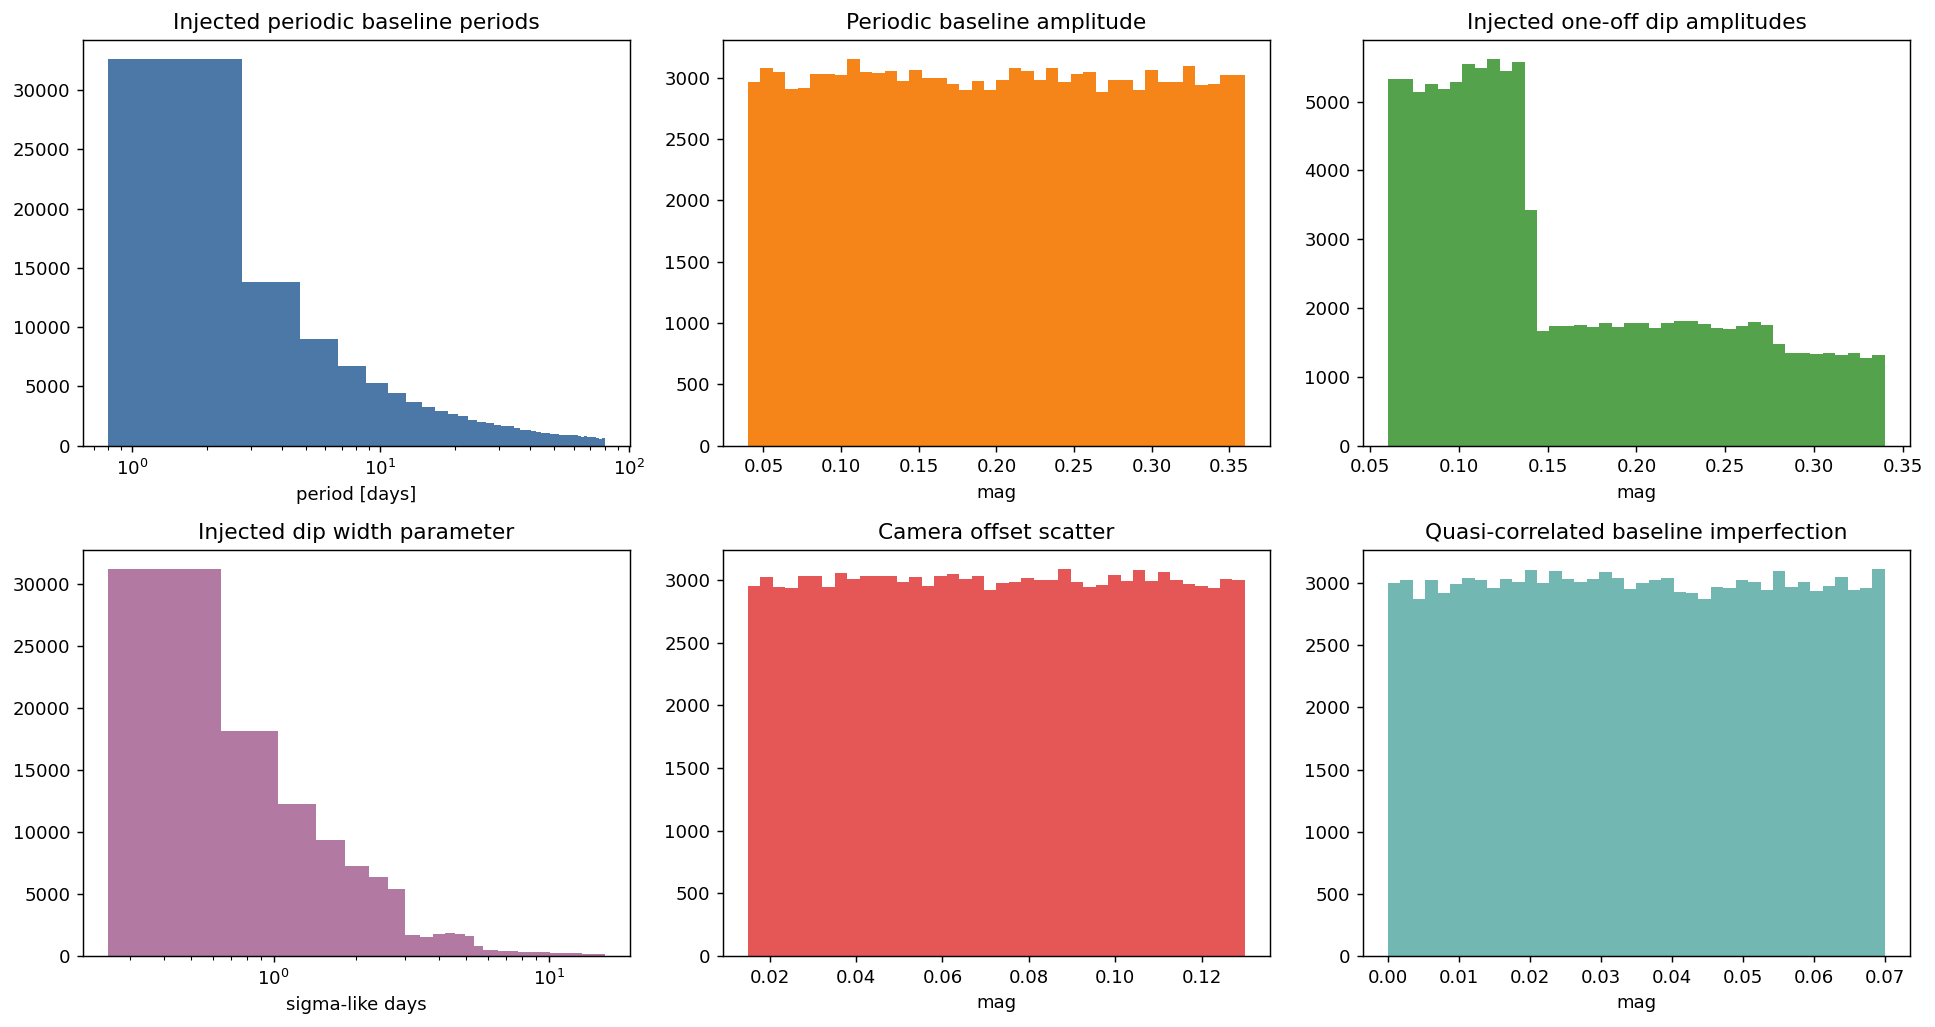

In [5]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

axes[0].hist(design["period_days"], bins=40, color="#4c78a8")
axes[0].set_xscale("log")
axes[0].set_title("Injected periodic baseline periods")
axes[0].set_xlabel("period [days]")

axes[1].hist(design["periodic_amp_mag"], bins=40, color="#f58518")
axes[1].set_title("Periodic baseline amplitude")
axes[1].set_xlabel("mag")

axes[2].hist(design.loc[design["has_dip"], "dip_amp_mag"], bins=40, color="#54a24b")
axes[2].set_title("Injected one-off dip amplitudes")
axes[2].set_xlabel("mag")

axes[3].hist(design.loc[design["has_dip"], "dip_sigma_days"], bins=40, color="#b279a2")
axes[3].set_xscale("log")
axes[3].set_title("Injected dip width parameter")
axes[3].set_xlabel("sigma-like days")

axes[4].hist(design["camera_offset_sigma_mag"], bins=40, color="#e45756")
axes[4].set_title("Camera offset scatter")
axes[4].set_xlabel("mag")

axes[5].hist(design["quasi_noise_amp_mag"], bins=40, color="#72b7b2")
axes[5].set_title("Quasi-correlated baseline imperfection")
axes[5].set_xlabel("mag")

finalize_publication_figure(fig)
fig.savefig(plots_dir / "simulation_design_distributions.png")
plt.show()


## Overall Branch Metrics

Definitions used below:

- `observable_recall`: fraction of injected dips with enough sampled support and peak S/N that are recovered with detected points overlapping the truth dip support.
- `precision_by_trial`: among trials with a significant dip detection, fraction where the detection overlaps an injected dip.
- `control_false_positive_rate`: significant dip detections in no-dip controls.
- `off_target_detection_rate`: injected-dip trials where a significant detection occurs away from the injected dip support.
- `phase_template_fallback_rate`: how often `phase_template_baseline` fell back to a non-phase baseline.

,mode,n,n_dip,n_observable_dip,n_control,observable_recall,all_dip_recall,precision_by_trial,control_false_positive_rate,off_target_detection_rate,phase_template_fallback_rate,median_baseline_mae_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio,median_dip_bayes_factor,median_dip_max_log_bf_local
0,gp_masked_control,113512,102108,74178,11404,0.020747,0.017511,0.092657,0.163364,0.153230,0.000000,0.143558,0.184698,1.768222,0.077334,5.117291
1,phase_template_1pct_period_error,119896,107891,78365,12005,0.002067,0.001529,0.405405,0.003249,0.001882,0.030143,0.057672,0.104225,1.264971,-1.193194,4.021486
2,phase_template_5pct_period_error,119923,107921,78395,12002,0.001518,0.001112,0.348837,0.001916,0.001862,0.030103,0.067670,0.116523,1.300443,-1.297192,3.716216
3,phase_template_true_period,119807,107802,78270,12005,0.005468,0.003989,0.717863,0.001666,0.001382,0.030416,0.038151,0.076465,1.162762,-1.478453,4.028943


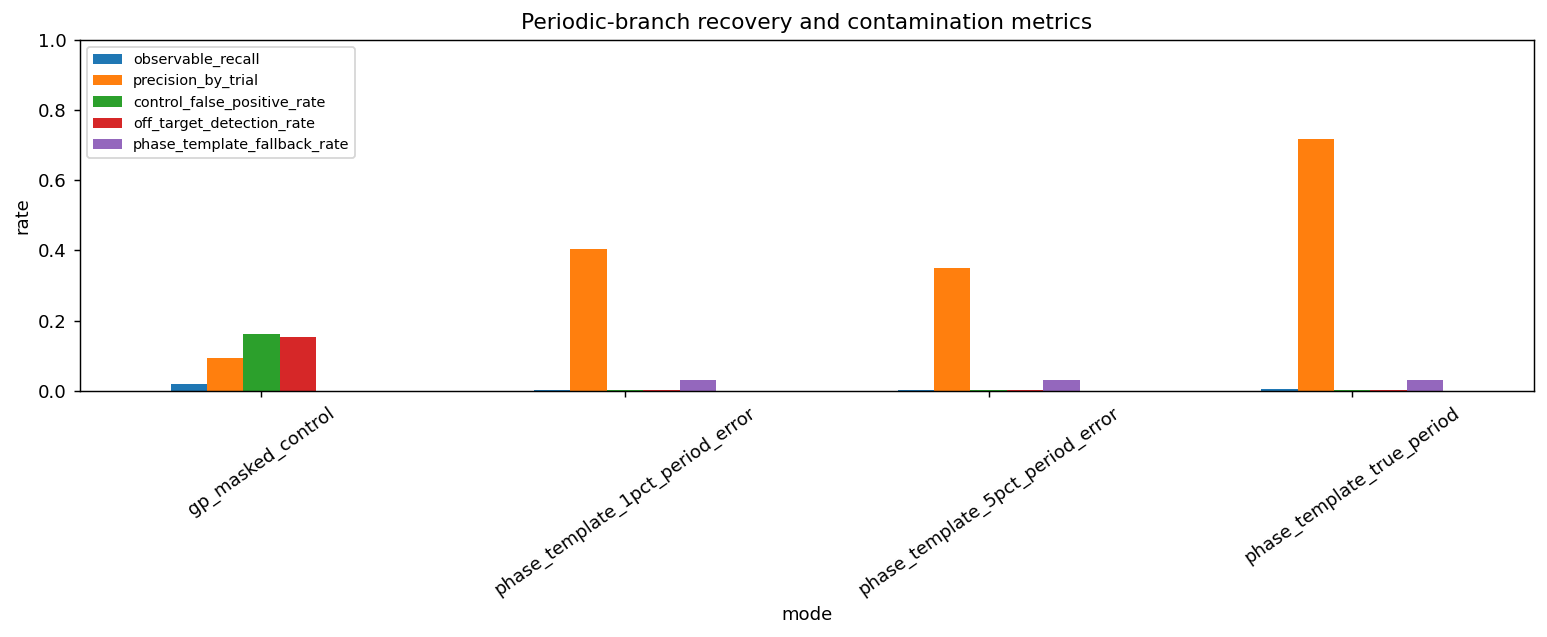

In [6]:
from malca.plotting.lightcurve_publication import (
    figsize_from_legacy,
    finalize_publication_figure,
)
overall = run.summary_overall.sort_values("mode")
metric_cols = [
    "mode", "n", "n_dip", "n_observable_dip", "n_control",
    "observable_recall", "all_dip_recall", "precision_by_trial", "control_false_positive_rate",
    "off_target_detection_rate", "phase_template_fallback_rate",
    "median_baseline_mae_outside_dip", "median_resid_rms_outside_dip", "median_amp_recovery_ratio",
    "median_dip_bayes_factor", "median_dip_max_log_bf_local",
]
display(overall[metric_cols])

fig, ax = plt.subplots(figsize=figsize_from_legacy(12, 5))
plot_overall_metrics(overall, ax=ax)
finalize_publication_figure(fig)
fig.savefig(plots_dir / "overall_branch_metrics.png")
plt.show()


## Slice Tables

These tables are meant to answer where the phase-folded path breaks: small amplitudes, sparse sampling, long periods, wide dips, complex periodic morphologies, or selected-period error.

In [7]:
for name in [
    "by_mode_and_dip_class",
    "by_mode_and_amp",
    "by_mode_and_period",
    "by_mode_and_width",
    "by_mode_and_points",
    "by_mode_and_waveform",
    "by_mode_and_period_error",
]:
    print(f"\n=== {name} ===")
    table = run.summary_slices[name].copy()
    display(table.sort_values([col for col in table.columns if col in {"mode", "dip_class", "dip_amp_bin", "period_bin", "width_bin", "points_bin_actual", "waveform_kind", "period_error_bin"}]).reset_index(drop=True))


=== by_mode_and_dip_class ===


,mode,dip_class,n,n_dip,n_observable_dip,n_control,status_error_rate,dip_significant_rate,observable_recall,all_dip_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,phase_template_fallback_rate,median_baseline_mae_outside_dip,median_baseline_rmse_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio,median_dip_bayes_factor,median_dip_max_log_bf_local
0,gp_masked_control,broad,9154,9154,8889,0,0.0,0.179047,0.039937,0.039546,NaN,0.139502,0.220866,0.000000,0.144876,0.179175,0.185298,2.150742,1.000839,5.594940
1,gp_masked_control,control_none,11404,0,0,11404,0.0,0.163364,NaN,NaN,0.163364,NaN,0.000000,0.000000,0.142512,0.177472,0.183851,NaN,-0.454096,4.611740
2,gp_masked_control,medium,36657,36657,31289,0,0.0,0.173309,0.024737,0.023324,NaN,0.149985,0.134582,0.000000,0.144254,0.178957,0.185571,1.491408,1.134214,5.908851
3,gp_masked_control,small,56297,56297,34000,0,0.0,0.167718,0.012059,0.010143,NaN,0.157575,0.060474,0.000000,0.143070,0.177920,0.184224,2.073213,-0.385776,4.683774
4,phase_template_1pct_period_error,broad,9664,9664,9369,0,0.0,0.003208,0.002028,0.001966,NaN,0.001242,0.612903,0.032906,0.059175,0.094499,0.106049,1.522083,-0.840420,4.419192
5,phase_template_1pct_period_error,control_none,12005,0,0,12005,0.0,0.003249,NaN,NaN,0.003249,NaN,0.000000,0.025739,0.057821,0.093212,0.104824,NaN,-1.419429,3.606544
6,phase_template_1pct_period_error,medium,38737,38737,32953,0,0.0,0.005447,0.004309,0.003666,NaN,0.001781,0.672986,0.030488,0.057469,0.092388,0.104061,1.142006,-0.809260,4.674491
7,phase_template_1pct_period_error,small,59490,59490,36043,0,0.0,0.002118,0.000028,0.000067,NaN,0.002051,0.031746,0.030358,0.057571,0.092427,0.103945,1.356205,-1.377183,3.687890
8,phase_template_5pct_period_error,broad,9664,9664,9370,0,0.0,0.003622,0.001921,0.001863,NaN,0.001759,0.514286,0.031974,0.068988,0.107966,0.117355,1.606217,-1.028025,4.075608
9,phase_template_5pct_period_error,control_none,12002,0,0,12002,0.0,0.001916,NaN,NaN,0.001916,NaN,0.000000,0.027495,0.068012,0.107594,0.117335,NaN,-1.429934,3.443427



=== by_mode_and_amp ===


,mode,dip_amp_bin,n,n_dip,n_observable_dip,n_control,status_error_rate,dip_significant_rate,observable_recall,all_dip_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,phase_template_fallback_rate,median_baseline_mae_outside_dip,median_baseline_rmse_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio,median_dip_bayes_factor,median_dip_max_log_bf_local
0,gp_masked_control,0.06-0.10,28276,28276,13915,0,0.0,0.165052,0.011355,0.009407,NaN,0.155644,0.056996,0.000000,0.143122,0.177961,0.184316,2.377405,-0.433753,4.611674
1,gp_masked_control,0.10-0.18,39360,39360,30087,0,0.0,0.170986,0.015621,0.013669,NaN,0.157317,0.079941,0.000000,0.143378,0.178047,0.184436,1.937958,-0.258658,4.825952
2,gp_masked_control,0.18-0.26,19035,19035,16851,0,0.0,0.174836,0.027595,0.025952,NaN,0.148884,0.148438,0.000000,0.144201,0.179148,0.185470,1.657011,1.101396,5.760019
3,gp_masked_control,0.26+,15437,15437,13325,0,0.0,0.175487,0.033471,0.031742,NaN,0.143746,0.180879,0.000000,0.144674,0.179189,0.185960,1.390507,2.078932,6.524836
4,gp_masked_control,control,11404,0,0,11404,0.0,0.163364,NaN,NaN,0.163364,NaN,0.000000,0.000000,0.142512,0.177472,0.183851,NaN,-0.454096,4.611740
5,phase_template_1pct_period_error,0.06-0.10,29893,29893,14858,0,0.0,0.002308,0.000067,0.000033,NaN,0.002275,0.014493,0.031512,0.057532,0.092641,0.104092,1.479396,-1.384994,3.642735
6,phase_template_1pct_period_error,0.10-0.18,41551,41551,31710,0,0.0,0.001998,0.000126,0.000168,NaN,0.001829,0.084337,0.030180,0.057726,0.092649,0.104180,1.321497,-1.341764,3.790045
7,phase_template_1pct_period_error,0.18-0.26,20091,20091,17719,0,0.0,0.003484,0.002201,0.001941,NaN,0.001543,0.557143,0.030511,0.057533,0.092063,0.103739,1.223011,-0.907902,4.497651
8,phase_template_1pct_period_error,0.26+,16356,16356,14078,0,0.0,0.008926,0.008382,0.007214,NaN,0.001712,0.808219,0.030325,0.057798,0.093124,0.104806,1.106480,-0.096799,5.431161
9,phase_template_1pct_period_error,control,12005,0,0,12005,0.0,0.003249,NaN,NaN,0.003249,NaN,0.000000,0.025739,0.057821,0.093212,0.104824,NaN,-1.419429,3.606544



=== by_mode_and_period ===


...

,mode,points_bin_actual,n,n_dip,n_observable_dip,n_control,status_error_rate,dip_significant_rate,observable_recall,all_dip_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,phase_template_fallback_rate,median_baseline_mae_outside_dip,median_baseline_rmse_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio,median_dip_bayes_factor,median_dip_max_log_bf_local
0,gp_masked_control,120-220,20474,18351,11949,2123,0.0,0.297304,0.046866,0.036619,0.276967,0.263037,0.110399,0.000000,0.140210,0.176134,0.182588,1.568842,49.204775,22.790233
1,gp_masked_control,220-360,30331,27304,19382,3027,0.0,0.179816,0.018729,0.014650,0.181037,0.165031,0.073341,0.000000,0.143987,0.178708,0.185058,1.726293,2.799458,6.230016
2,gp_masked_control,360-520,35314,31755,24370,3559,0.0,0.107691,0.010217,0.008345,0.099747,0.100236,0.069682,0.000000,0.145268,0.179522,0.186124,1.866935,-1.558420,3.606121
3,gp_masked_control,520+,21721,19552,15480,2169,0.0,0.078127,0.007946,0.006495,0.071462,0.072371,0.074838,0.000000,0.145242,0.178946,0.185450,1.935809,-1.731755,3.183457
4,gp_masked_control,<120,5672,5146,2997,526,0.0,0.397743,0.081415,0.062962,0.412548,0.333269,0.143617,0.000000,0.134433,0.172413,0.179656,1.391651,90.897761,36.679805
5,phase_template_1pct_period_error,120-220,22648,20319,13280,2329,0.0,0.003488,0.002033,0.001378,0.003864,0.002067,0.354430,0.002031,0.056865,0.092685,0.103459,1.135809,-0.969803,3.916972
6,phase_template_1pct_period_error,220-360,31716,28562,20340,3154,0.0,0.002806,0.001672,0.001190,0.001902,0.001716,0.382022,0.000000,0.056770,0.090784,0.102656,1.233594,-1.296936,3.975880
7,phase_template_1pct_period_error,360-520,36328,32670,25102,3658,0.0,0.002753,0.001793,0.001377,0.003280,0.001316,0.450000,0.000000,0.056988,0.090943,0.102821,1.318857,-1.392288,4.126846
8,phase_template_1pct_period_error,520+,22246,20023,15868,2223,0.0,0.003686,0.003214,0.002547,0.002249,0.001299,0.621951,0.000000,0.056636,0.090508,0.102834,1.359852,-1.423886,4.252043
9,phase_template_1pct_period_error,<120,6958,6317,3775,641,0.0,0.008192,0.001325,0.001108,0.010920,0.006807,0.122807,0.512791,0.077714,0.131118,0.138413,1.133637,-0.596212,3.130117



=== by_mode_and_waveform ===


,mode,waveform_kind,n,n_dip,n_observable_dip,n_control,status_error_rate,dip_significant_rate,observable_recall,all_dip_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,phase_template_fallback_rate,median_baseline_mae_outside_dip,median_baseline_rmse_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio,median_dip_bayes_factor,median_dip_max_log_bf_local
0,gp_masked_control,broad_eclipse,22402,20181,14645,2221,0.0,0.174315,0.024923,0.020316,0.169293,0.154551,0.104994,0.000000,0.134670,0.163760,0.170727,1.737897,11.699584,8.110165
1,gp_masked_control,double_wave,22905,20580,14924,2325,0.0,0.167169,0.020638,0.017055,0.164731,0.150389,0.091669,0.000000,0.142735,0.179654,0.185908,1.750186,-0.737552,4.603654
2,gp_masked_control,mixed,22733,20490,14820,2243,0.0,0.169577,0.019636,0.016740,0.164066,0.153441,0.088975,0.000000,0.142888,0.179918,0.186566,1.778229,-0.819250,4.584743
3,gp_masked_control,sinusoid,22936,20581,15119,2355,0.0,0.173090,0.020372,0.017443,0.162633,0.156844,0.090428,0.000000,0.149990,0.186953,0.193207,1.796643,-1.274505,4.041057
4,gp_masked_control,spot_like,22536,20276,14670,2260,0.0,0.165868,0.018200,0.016029,0.156195,0.150917,0.086945,0.000000,0.144871,0.179922,0.186283,1.783497,-0.910676,4.496441
5,phase_template_1pct_period_error,broad_eclipse,23923,21549,15655,2374,0.0,0.005309,0.003002,0.002227,0.005055,0.003109,0.377953,0.030974,0.048978,0.084441,0.096879,1.251500,0.649839,5.302891
6,phase_template_1pct_period_error,double_wave,24106,21686,15719,2420,0.0,0.003153,0.002163,0.001568,0.002893,0.001614,0.447368,0.029702,0.059081,0.093653,0.104831,1.261225,-1.416438,3.771797
7,phase_template_1pct_period_error,mixed,23950,21567,15609,2383,0.0,0.002923,0.001602,0.001206,0.002518,0.001762,0.371429,0.030397,0.059244,0.093889,0.105419,1.273518,-1.373764,3.809910
8,phase_template_1pct_period_error,sinusoid,24152,21697,15915,2455,0.0,0.002484,0.001320,0.000968,0.003666,0.001383,0.350000,0.029107,0.065127,0.099755,0.110428,1.281162,-1.451847,3.596626
9,phase_template_1pct_period_error,spot_like,23765,21392,15467,2373,0.0,0.003114,0.002263,0.001683,0.002107,0.001543,0.486486,0.030549,0.059879,0.093942,0.105567,1.262019,-1.306657,3.832458



=== by_mode_and_period_error ===


,mode,period_error_bin,n,n_dip,n_observable_dip,n_control,status_error_rate,dip_significant_rate,observable_recall,all_dip_recall,control_false_positive_rate,off_target_detection_rate,precision_by_trial,phase_template_fallback_rate,median_baseline_mae_outside_dip,median_baseline_rmse_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio,median_dip_bayes_factor,median_dip_max_log_bf_local
0,gp_masked_control,nan,113512,102108,74178,11404,0.0,0.170000,0.020747,0.017511,0.163364,0.153230,0.092657,0.000000,0.143558,0.178273,0.184698,1.768222,0.077334,5.117291
1,phase_template_1pct_period_error,0.1-1%,72533,65245,47428,7288,0.0,0.003626,0.002319,0.001717,0.003705,0.001901,0.425856,0.030607,0.056373,0.090995,0.102688,1.264219,-1.146203,4.100715
2,phase_template_1pct_period_error,1-3%,37472,33754,24462,3718,0.0,0.002936,0.001390,0.001037,0.002959,0.001896,0.318182,0.029329,0.065683,0.105289,0.115128,1.295071,-1.251241,3.835790
3,phase_template_1pct_period_error,3-8%,352,311,223,41,0.0,0.002841,0.000000,0.000000,0.000000,0.003215,0.000000,0.039773,0.072721,0.111506,0.121555,1.244958,-1.356270,3.660980
4,phase_template_1pct_period_error,none/<0.1%,9539,8581,6252,958,0.0,0.003459,0.002879,0.002098,0.001044,0.001632,0.545455,0.029458,0.041797,0.066996,0.082384,1.185073,-1.295200,4.204187
5,phase_template_5pct_period_error,0.1-1%,17096,15379,11190,1717,0.0,0.003685,0.002413,0.001756,0.002912,0.002016,0.428571,0.032815,0.057584,0.092559,0.104034,1.253484,-1.171336,4.048937
6,phase_template_5pct_period_error,1-3%,35251,31693,23007,3558,0.0,0.003177,0.001304,0.000947,0.002811,0.002272,0.267857,0.030552,0.067407,0.107380,0.116935,1.312834,-1.248239,3.792313
7,phase_template_5pct_period_error,3-8%,52661,47396,34397,5265,0.0,0.002583,0.001395,0.001034,0.001140,0.001709,0.360294,0.029016,0.071154,0.110985,0.120582,1.312721,-1.338661,3.617849
8,phase_template_5pct_period_error,8%+,13033,11731,8546,1302,0.0,0.001688,0.000585,0.000426,0.001536,0.001279,0.227273,0.030231,0.073742,0.113137,0.122664,1.311891,-1.382679,3.471971
9,phase_template_5pct_period_error,none/<0.1%,1882,1722,1255,160,0.0,0.005845,0.007171,0.005226,0.000000,0.001161,0.818182,0.026567,0.042227,0.066819,0.082366,1.180751,-1.307277,4.177247


## Recovery Heatmaps

The first grid shows target recovery by dip amplitude and period. The second grid shows the median outside-dip residual RMS over the same population, which is a compact baseline-quality diagnostic.

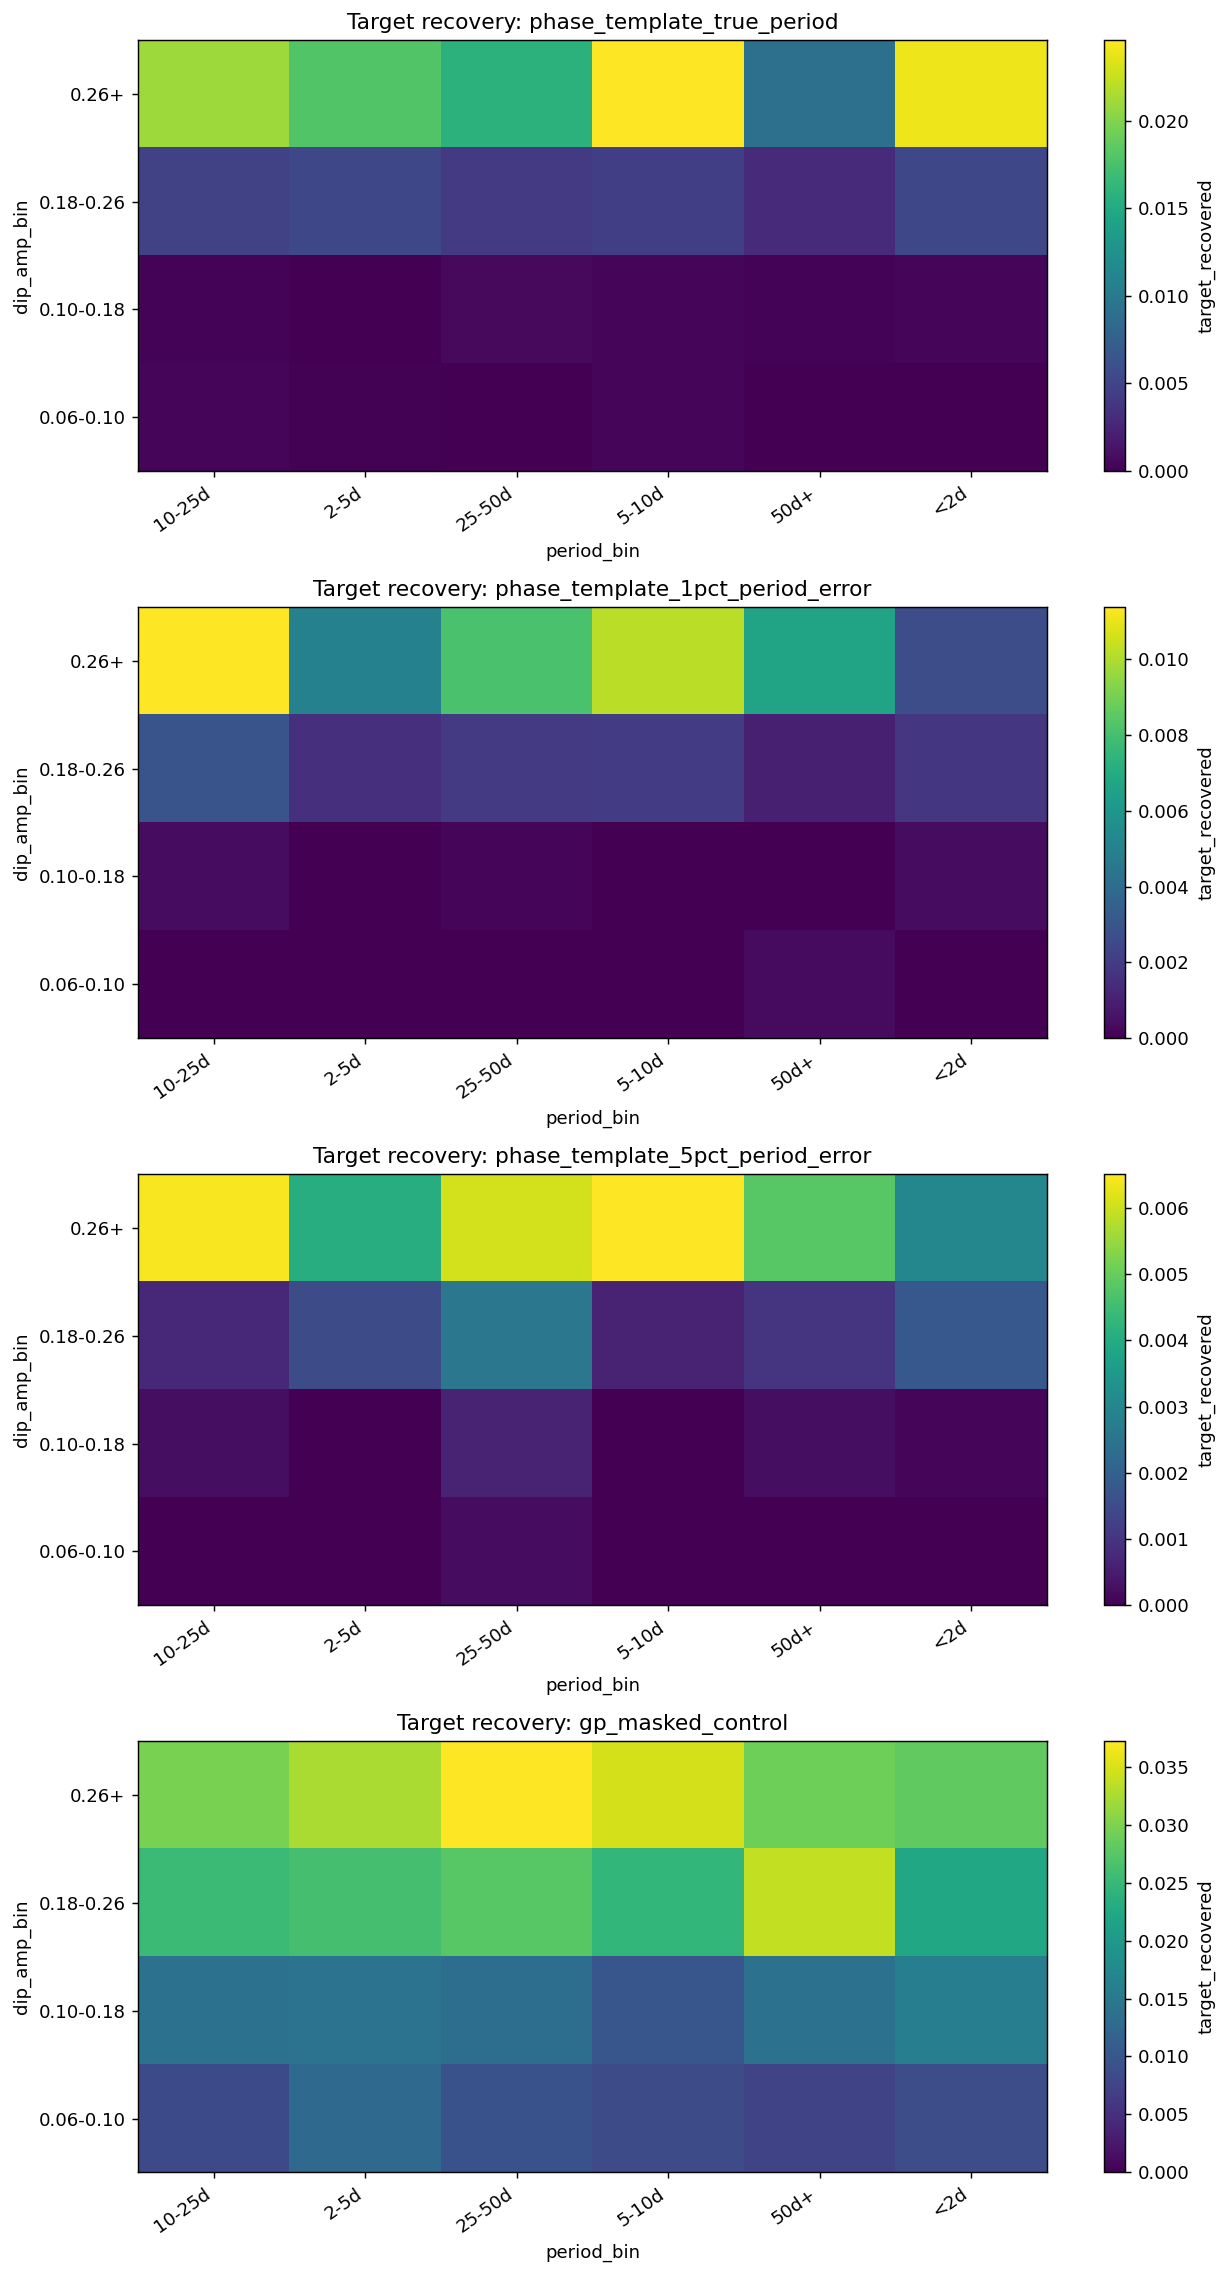

In [8]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
plot_modes = list(config.mode_names)
fig, axes = plt.subplots(len(plot_modes), 1, figsize=(10, 4.4 * len(plot_modes)))
if len(plot_modes) == 1:
    axes = [axes]
for ax, mode in zip(axes, plot_modes):
    metric_heatmap(
        results[results["has_dip"].fillna(False)],
        mode=mode,
        row="dip_amp_bin",
        col="period_bin",
        metric="target_recovered",
        title=f"Target recovery: {mode}",
        ax=ax,
    )
finalize_publication_figure(fig)
fig.savefig(plots_dir / "heatmap_recovery_amp_period.png")
plt.show()


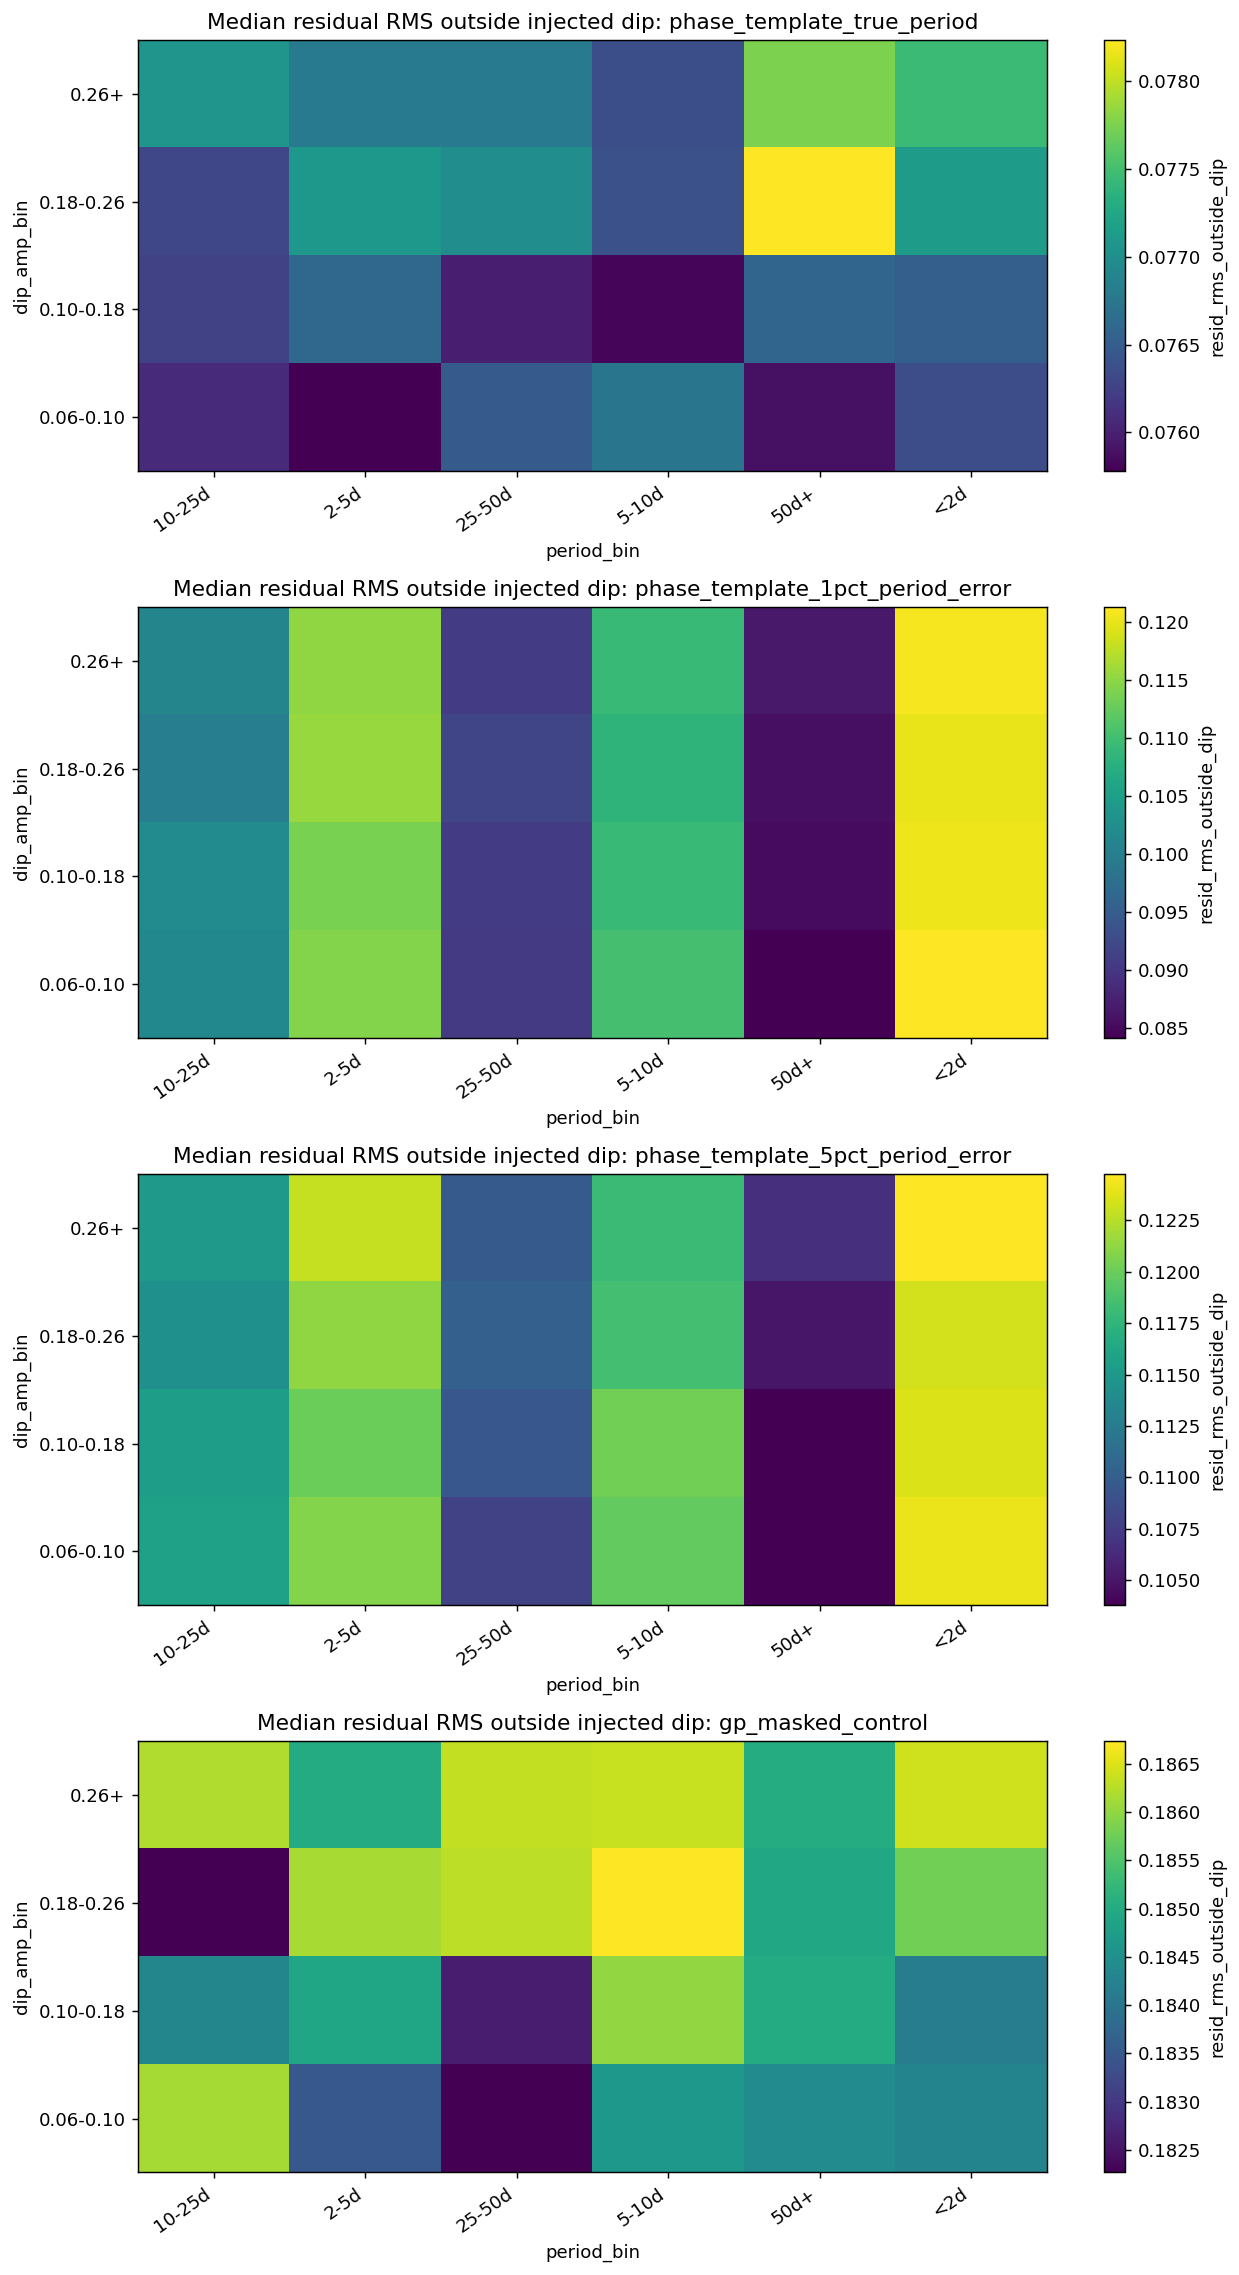

In [9]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
fig, axes = plt.subplots(len(plot_modes), 1, figsize=(10, 4.4 * len(plot_modes)))
if len(plot_modes) == 1:
    axes = [axes]
for ax, mode in zip(axes, plot_modes):
    metric_heatmap(
        results[results["has_dip"].fillna(False)],
        mode=mode,
        row="dip_amp_bin",
        col="period_bin",
        metric="resid_rms_outside_dip",
        title=f"Median residual RMS outside injected dip: {mode}",
        ax=ax,
    )
finalize_publication_figure(fig)
fig.savefig(plots_dir / "heatmap_residual_rms_amp_period.png")
plt.show()


## Baseline Quality And Event Evidence Distributions

A useful branch should both recover dips and leave quiet residuals outside the injected event. These distributions expose baseline absorption, excess residual structure, and selected-period sensitivity.

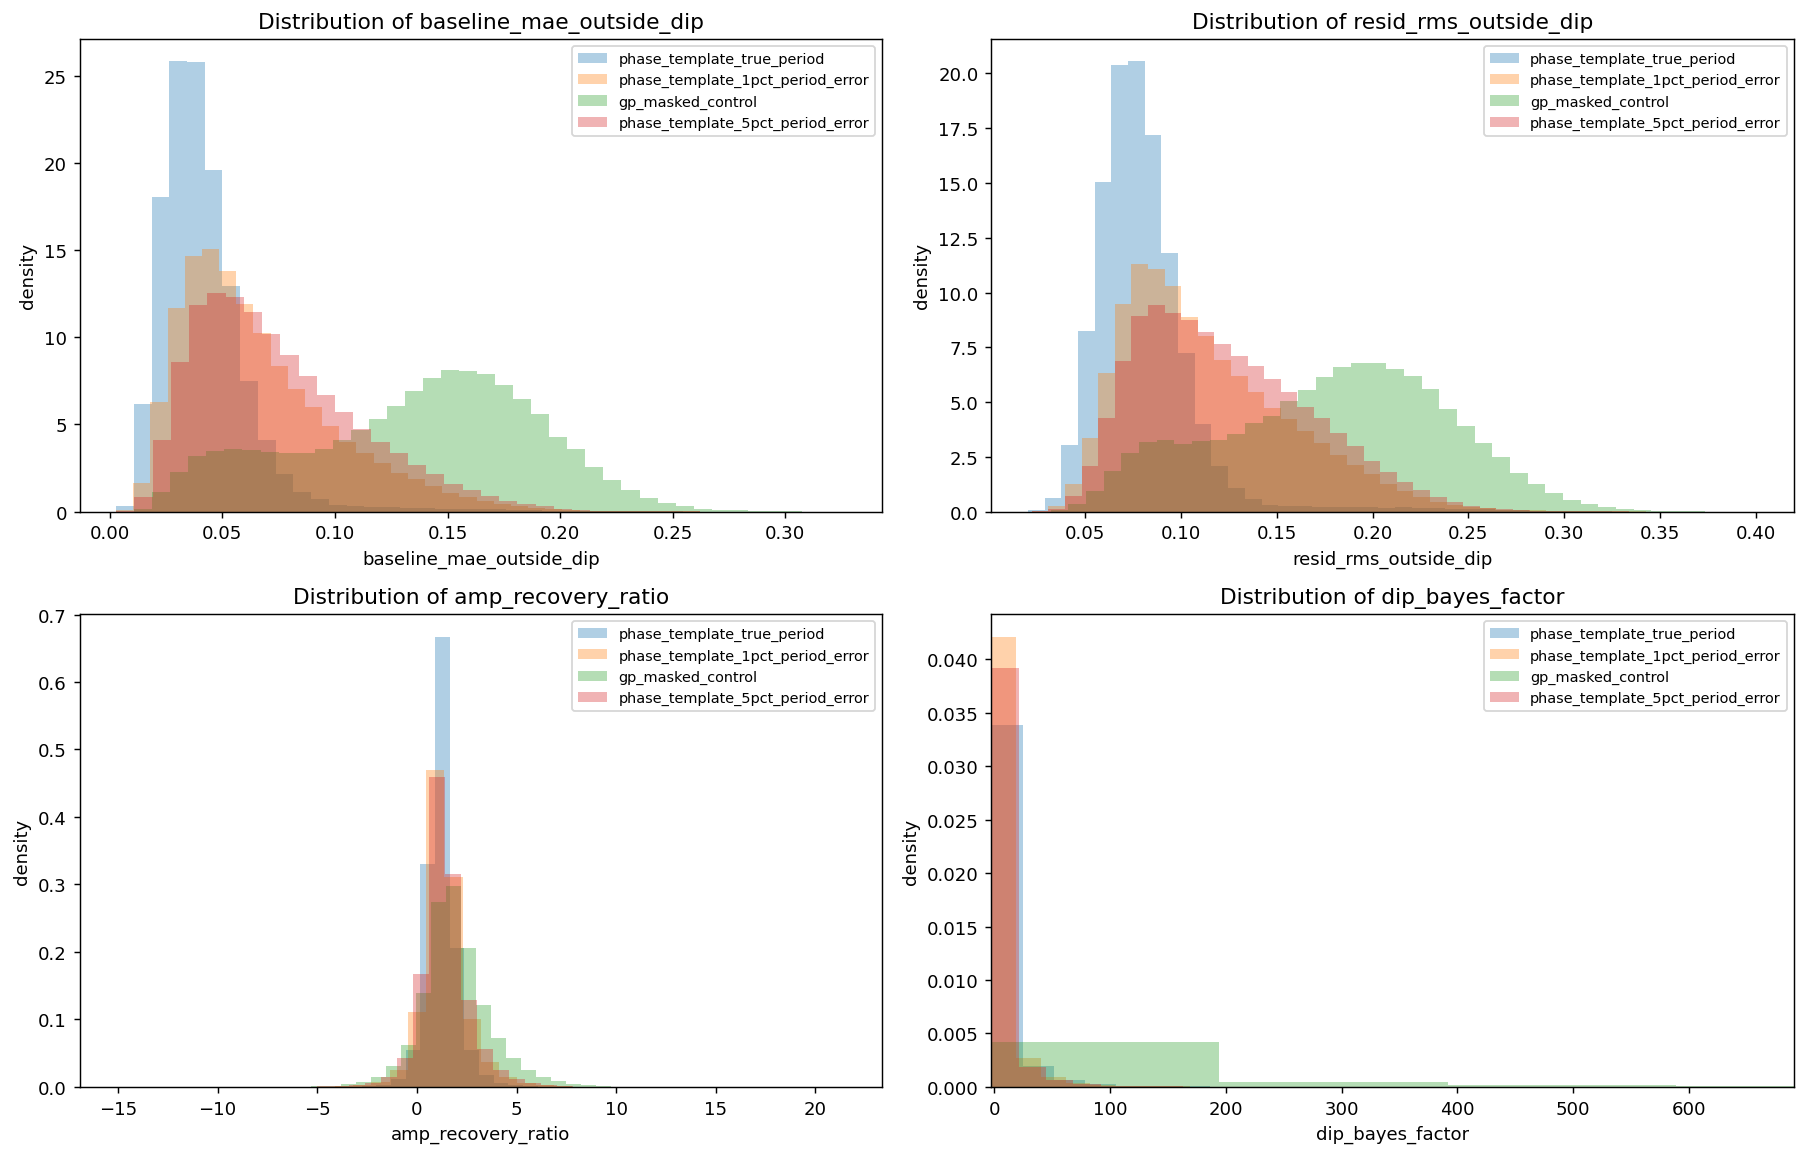

In [10]:
from malca.plotting.lightcurve_publication import finalize_publication_figure
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_metric_distributions(results, metric="baseline_mae_outside_dip", ax=axes[0, 0])
plot_metric_distributions(results, metric="resid_rms_outside_dip", ax=axes[0, 1])
plot_metric_distributions(results[results["has_dip"].fillna(False)], metric="amp_recovery_ratio", ax=axes[1, 0])
plot_metric_distributions(results, metric="dip_bayes_factor", ax=axes[1, 1])
axes[1, 1].set_xlim(np.nanpercentile(results["dip_bayes_factor"], 1), np.nanpercentile(results["dip_bayes_factor"], 99))
finalize_publication_figure(fig)
fig.savefig(plots_dir / "baseline_and_evidence_distributions.png")
plt.show()


In [11]:
# Pairwise per-trial comparison of phase-template true-period mode against the GP-masked control when both are present.
if {"phase_template_true_period", "gp_masked_control"}.issubset(set(results["mode"])):
    pair_cols = [
        "trial_id", "mode", "target_recovered", "dip_significant", "baseline_mae_outside_dip",
        "resid_rms_outside_dip", "dip_bayes_factor", "has_dip", "truth_observable_actual", "dip_amp_mag", "period_days",
    ]
    pair = results.loc[results["mode"].isin(["phase_template_true_period", "gp_masked_control"]), pair_cols]
    wide = pair.pivot(index="trial_id", columns="mode")
    compare = pd.DataFrame(index=wide.index)
    compare["has_dip"] = wide[("has_dip", "phase_template_true_period")]
    compare["truth_observable"] = wide[("truth_observable_actual", "phase_template_true_period")]
    compare["dip_amp_mag"] = wide[("dip_amp_mag", "phase_template_true_period")]
    compare["period_days"] = wide[("period_days", "phase_template_true_period")]
    compare["phase_recovered"] = wide[("target_recovered", "phase_template_true_period")]
    compare["gp_recovered"] = wide[("target_recovered", "gp_masked_control")]
    compare["phase_minus_gp_resid_rms"] = wide[("resid_rms_outside_dip", "phase_template_true_period")] - wide[("resid_rms_outside_dip", "gp_masked_control")]
    compare["phase_minus_gp_baseline_mae"] = wide[("baseline_mae_outside_dip", "phase_template_true_period")] - wide[("baseline_mae_outside_dip", "gp_masked_control")]
    compare["phase_minus_gp_bayes_factor"] = wide[("dip_bayes_factor", "phase_template_true_period")] - wide[("dip_bayes_factor", "gp_masked_control")]

    display(pd.crosstab(compare["phase_recovered"], compare["gp_recovered"], rownames=["phase recovered"], colnames=["gp recovered"], margins=True))
    display(compare.sort_values("phase_minus_gp_resid_rms").head(15))
    display(compare.sort_values("phase_minus_gp_resid_rms", ascending=False).head(15))
else:
    print("Skipping phase-vs-GP paired comparison because one of the modes is absent.")

gp recovered,False,True,All
phase recovered,,,
False,111223,1741,112964
True,351,37,388
All,111574,1778,113352


,has_dip,truth_observable,dip_amp_mag,period_days,phase_recovered,gp_recovered,phase_minus_gp_resid_rms,phase_minus_gp_baseline_mae,phase_minus_gp_bayes_factor
trial_id,,,,,,,,,
43044,True,True,0.092744,4.750219,False,False,-0.290587,-0.221220,-0.731007
11138,True,False,0.087920,10.360156,False,False,-0.288667,-0.251106,-0.599788
4336,True,True,0.091523,72.027486,False,False,-0.286865,-0.276496,-268.147848
110138,True,True,0.210090,14.479989,False,False,-0.286737,-0.261043,20.837792
79227,True,True,0.090839,19.057398,False,False,-0.281324,-0.168790,-0.499446
3360,True,True,0.255680,32.717576,False,False,-0.280597,-0.239247,-0.706147
85560,False,False,0.000000,1.488605,False,False,-0.279964,-0.262086,-192.185106
18945,False,False,0.000000,0.881111,False,False,-0.278932,-0.245023,-0.736395
7543,True,True,0.152578,39.235633,False,False,-0.278166,-0.284458,-0.696315


,has_dip,truth_observable,dip_amp_mag,period_days,phase_recovered,gp_recovered,phase_minus_gp_resid_rms,phase_minus_gp_baseline_mae,phase_minus_gp_bayes_factor
trial_id,,,,,,,,,
7789,True,True,0.135511,1.620618,False,False,0.067133,0.043524,-1428.691709
9492,True,True,0.250569,20.997532,False,False,0.063646,0.021475,-481.897309
3709,True,True,0.229764,3.864679,False,False,0.063135,0.012252,21.039531
88926,True,True,0.198388,34.230872,False,False,0.060267,0.040995,-68.332244
14621,True,True,0.078683,6.505712,False,False,0.058327,0.041388,-267.095318
15479,True,True,0.234686,3.510028,False,False,0.056045,0.081491,-146.593708
64535,True,False,0.086284,5.118988,False,False,0.056010,0.008292,0.266287
14370,True,True,0.085721,2.001833,False,False,0.054776,0.044060,-600.666986
25630,True,True,0.247141,17.872383,False,False,0.054385,-0.004850,-423.529302


## Misses, Off-Target Detections, And False Positives

The next tables are the highest-signal debugging surfaces. They list observable injected dips that the branch missed, injected-dip trials with significant detections away from the injected dip, and no-dip controls with false positive detections.

In [12]:
inspect_cols = [
    "trial_id", "mode", "dip_class", "dip_amp_mag", "dip_sigma_days", "truth_support_points_actual", "truth_peak_snr_actual",
    "period_days", "n_points_actual", "n_cameras_actual", "waveform_kind", "periodic_amp_mag", "phase_wander_cycles",
    "quasi_noise_amp_mag", "camera_offset_sigma_mag", "selected_period_days", "period_frac_error",
    "dip_significant", "target_recovered", "off_target_detection", "dip_bayes_factor", "dip_max_log_bf_local",
    "dip_run_count", "dip_max_run_points", "baseline_source", "baseline_mae_outside_dip", "resid_rms_outside_dip",
    "amp_recovery_ratio", "error",
]

ok = results[results["status"].eq("ok")].copy()
misses = ok[
    ok["has_dip"].fillna(False).astype(bool)
    & ok["truth_observable_actual"].fillna(False).astype(bool)
    & ~ok["target_recovered"].fillna(False).astype(bool)
]
off_target = ok[ok["off_target_detection"].fillna(False).astype(bool)]
control_fp = ok[ok["false_positive"].fillna(False).astype(bool)]

print(f"Observable misses: {len(misses):,}")
display(misses.sort_values(["dip_amp_mag", "truth_peak_snr_actual"], ascending=[False, False])[inspect_cols].head(30))

print(f"Off-target detections: {len(off_target):,}")
display(off_target.sort_values("dip_bayes_factor", ascending=False)[inspect_cols].head(30))

print(f"Control false positives: {len(control_fp):,}")
display(control_fp.sort_values("dip_bayes_factor", ascending=False)[inspect_cols].head(30))

/tmp/ipykernel_2398239/931073298.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ok["truth_observable_actual"].fillna(False).astype(bool)
/tmp/ipykernel_2398239/931073298.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~ok["target_recovered"].fillna(False).astype(bool)
/tmp/ipykernel_2398239/931073298.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_

Observable misses: 306,960


,trial_id,mode,dip_class,dip_amp_mag,dip_sigma_days,truth_support_points_actual,truth_peak_snr_actual,period_days,n_points_actual,n_cameras_actual,waveform_kind,periodic_amp_mag,phase_wander_cycles,quasi_noise_amp_mag,camera_offset_sigma_mag,selected_period_days,period_frac_error,dip_significant,target_recovered,off_target_detection,dip_bayes_factor,dip_max_log_bf_local,dip_run_count,dip_max_run_points,baseline_source,baseline_mae_outside_dip,resid_rms_outside_dip,amp_recovery_ratio,error
342675,85669,phase_template_true_period,medium,0.339997,0.618706,2.0,4.817437,3.766433,526.0,2.0,double_wave,0.116664,0.044414,0.004756,0.071806,3.766433,0.000000,False,False,False,-2.437351,3.333957,0.0,0.0,phase_template,0.040738,0.078314,1.007983,
342676,85669,phase_template_1pct_period_error,medium,0.339997,0.618706,2.0,4.817437,3.766433,526.0,2.0,double_wave,0.116664,0.044414,0.004756,0.071806,3.738999,0.007284,False,False,False,-2.066282,4.521936,0.0,0.0,phase_template,0.051573,0.092355,1.210277,
342677,85669,phase_template_5pct_period_error,medium,0.339997,0.618706,2.0,4.817437,3.766433,526.0,2.0,double_wave,0.116664,0.044414,0.004756,0.071806,3.761764,0.001240,False,False,False,-2.131457,4.745063,0.0,0.0,phase_template,0.034679,0.091750,1.105223,
342678,85669,gp_masked_control,medium,0.339997,0.618706,2.0,4.817437,3.766433,526.0,2.0,double_wave,0.116664,0.044414,0.004756,0.071806,NaN,NaN,False,False,False,-1.921449,1.954525,0.0,0.0,unknown,0.121128,0.161117,0.973422,
348044,87011,phase_template_1pct_period_error,medium,0.339996,1.516795,6.0,17.049896,17.266588,351.0,2.0,double_wave,0.263317,0.028324,0.021821,0.108668,17.206100,0.003503,False,False,False,-1.756611,5.720391,0.0,0.0,phase_template,0.075299,0.119012,1.343749,
348045,87011,phase_template_true_period,medium,0.339996,1.516795,6.0,17.049896,17.266588,351.0,2.0,double_wave,0.263317,0.028324,0.021821,0.108668,17.266588,0.000000,False,False,False,49.081519,15.127461,0.0,0.0,phase_template,0.034052,0.057106,1.206888,
348046,87011,phase_template_5pct_period_error,medium,0.339996,1.516795,6.0,17.049896,17.266588,351.0,2.0,double_wave,0.263317,0.028324,0.021821,0.108668,15.740505,0.088384,False,False,False,-2.170945,3.357580,0.0,0.0,phase_template,0.104498,0.149608,0.832155,
348048,87011,gp_masked_control,medium,0.339996,1.516795,6.0,17.049896,17.266588,351.0,2.0,double_wave,0.263317,0.028324,0.021821,0.108668,NaN,NaN,False,False,False,19.224974,26.888698,0.0,0.0,unknown,0.187683,0.243933,1.606675,
284161,71041,phase_template_true_period,medium,0.339985,5.304827,9.0,13.321227,0.893708,526.0,2.0,broad_eclipse,0.339844,0.029681,0.026052,0.124754,0.893708,0.000000,False,False,False,-2.413639,5.380869,0.0,0.0,phase_template,0.047176,0.104637,0.655051,
284164,71041,phase_template_1pct_period_error,medium,0.339985,5.304827,9.0,13.321227,0.893708,526.0,2.0,broad_eclipse,0.339844,0.029681,0.026052,0.124754,0.907663,0.015615,False,False,False,-1.750428,2.588642,0.0,0.0,phase_template,0.095735,0.169576,1.029955,


Off-target detections: 16,199


,trial_id,mode,dip_class,dip_amp_mag,dip_sigma_days,truth_support_points_actual,truth_peak_snr_actual,period_days,n_points_actual,n_cameras_actual,waveform_kind,periodic_amp_mag,phase_wander_cycles,quasi_noise_amp_mag,camera_offset_sigma_mag,selected_period_days,period_frac_error,dip_significant,target_recovered,off_target_detection,dip_bayes_factor,dip_max_log_bf_local,dip_run_count,dip_max_run_points,baseline_source,baseline_mae_outside_dip,resid_rms_outside_dip,amp_recovery_ratio,error
427269,106814,gp_masked_control,small,0.114931,0.629887,3.0,4.277477,1.628868,269.0,5.0,spot_like,0.349533,0.024810,0.035294,0.119766,NaN,NaN,True,False,True,7880.961251,2524.884816,1.0,2.0,unknown,0.206969,0.296391,-4.141254,
286197,71546,gp_masked_control,broad,0.221771,14.986750,5.0,16.486014,50.983033,136.0,5.0,sinusoid,0.213290,0.009297,0.013232,0.065980,NaN,NaN,True,False,True,7415.295428,1748.847712,3.0,3.0,unknown,0.146689,0.230127,1.496014,
388303,97069,gp_masked_control,small,0.116081,0.769451,2.0,8.377124,1.198567,142.0,5.0,double_wave,0.268752,0.031250,0.040183,0.075040,NaN,NaN,True,False,True,7081.684862,1531.575184,4.0,3.0,unknown,0.202352,0.246223,1.324857,
464602,116149,gp_masked_control,small,0.109462,1.437433,1.0,5.937289,19.570078,356.0,5.0,spot_like,0.282950,0.001847,0.038298,0.076279,NaN,NaN,True,False,True,7059.713900,3435.962262,2.0,2.0,unknown,0.253361,0.290853,3.453659,
124139,31021,gp_masked_control,small,0.132302,0.390243,1.0,6.266815,14.233196,246.0,4.0,sinusoid,0.343474,0.002256,0.011614,0.067982,NaN,NaN,True,False,True,6381.682933,1807.605785,6.0,3.0,unknown,0.231237,0.280065,-1.837199,
185050,46254,gp_masked_control,medium,0.175405,1.045286,2.0,16.650783,0.869832,282.0,4.0,mixed,0.346949,0.018664,0.040678,0.084797,NaN,NaN,True,False,True,6310.979249,2255.146407,3.0,4.0,unknown,0.200451,0.307242,1.305033,
180600,45148,gp_masked_control,medium,0.192908,1.379454,3.0,15.001811,7.868322,374.0,4.0,sinusoid,0.261907,0.005844,0.046316,0.099856,NaN,NaN,True,False,True,6212.589096,1723.471584,2.0,2.0,unknown,0.281416,0.306482,3.807085,
473606,118396,gp_masked_control,small,0.119680,0.407673,1.0,7.297320,2.450243,100.0,5.0,broad_eclipse,0.063718,0.019225,0.033759,0.088572,NaN,NaN,True,False,True,5914.085071,670.554691,4.0,11.0,unknown,0.248554,0.269753,-1.866591,
405005,101249,gp_masked_control,small,0.112534,0.540571,5.0,7.231582,38.743116,347.0,5.0,sinusoid,0.305895,0.035814,0.000728,0.024716,NaN,NaN,True,False,True,5897.696964,1568.729020,2.0,2.0,unknown,0.255342,0.309917,2.695944,
437580,109393,gp_masked_control,medium,0.209311,0.856478,3.0,16.248624,36.644758,264.0,5.0,spot_like,0.280800,0.046788,0.066897,0.078485,NaN,NaN,True,False,True,5827.068499,1865.803371,1.0,2.0,unknown,0.206522,0.275817,-0.826569,


Control false positives: 1,945


,trial_id,mode,dip_class,dip_amp_mag,dip_sigma_days,truth_support_points_actual,truth_peak_snr_actual,period_days,n_points_actual,n_cameras_actual,waveform_kind,periodic_amp_mag,phase_wander_cycles,quasi_noise_amp_mag,camera_offset_sigma_mag,selected_period_days,period_frac_error,dip_significant,target_recovered,off_target_detection,dip_bayes_factor,dip_max_log_bf_local,dip_run_count,dip_max_run_points,baseline_source,baseline_mae_outside_dip,resid_rms_outside_dip,amp_recovery_ratio,error
479014,119745,gp_masked_control,control_none,0.0,NaN,0.0,0.0,9.898202,135.0,5.0,broad_eclipse,0.221360,0.047746,0.012518,0.054081,NaN,NaN,True,False,False,4788.008472,936.415386,3.0,4.0,unknown,0.187217,0.226751,NaN,
316194,79045,gp_masked_control,control_none,0.0,NaN,0.0,0.0,1.679128,381.0,4.0,mixed,0.326207,0.010382,0.021985,0.073921,NaN,NaN,True,False,False,4777.697449,1190.753691,4.0,3.0,unknown,0.196340,0.301008,NaN,
305871,76460,gp_masked_control,control_none,0.0,NaN,0.0,0.0,10.084588,173.0,5.0,sinusoid,0.252187,0.012118,0.042531,0.099279,NaN,NaN,True,False,False,4555.804327,2237.761711,2.0,3.0,unknown,0.227251,0.254344,NaN,
283316,70825,gp_masked_control,control_none,0.0,NaN,0.0,0.0,17.338551,126.0,5.0,sinusoid,0.335115,0.045085,0.062254,0.061894,NaN,NaN,True,False,False,4251.179376,1229.374850,3.0,2.0,unknown,0.192915,0.269896,NaN,
187384,46844,gp_masked_control,control_none,0.0,NaN,0.0,0.0,11.137917,611.0,5.0,double_wave,0.281299,0.002362,0.010527,0.092253,NaN,NaN,True,False,False,3872.825444,1458.528251,1.0,2.0,unknown,0.214437,0.245449,NaN,
445615,111393,gp_masked_control,control_none,0.0,NaN,0.0,0.0,46.981242,207.0,4.0,mixed,0.211407,0.014410,0.052256,0.083779,NaN,NaN,True,False,False,3736.595946,839.833606,4.0,3.0,unknown,0.186390,0.228150,NaN,
183642,45907,gp_masked_control,control_none,0.0,NaN,0.0,0.0,72.742324,275.0,5.0,broad_eclipse,0.342331,0.034828,0.032365,0.028373,NaN,NaN,True,False,False,3694.534958,3172.383175,2.0,2.0,unknown,0.165243,0.206759,NaN,
55853,13961,gp_masked_control,control_none,0.0,NaN,0.0,0.0,66.933696,133.0,2.0,sinusoid,0.346144,0.007904,0.046064,0.094341,NaN,NaN,True,False,False,3572.278177,1733.083096,1.0,2.0,unknown,0.132851,0.267699,NaN,
276298,69069,gp_masked_control,control_none,0.0,NaN,0.0,0.0,9.491721,355.0,4.0,spot_like,0.232116,0.009267,0.061834,0.114966,NaN,NaN,True,False,False,3527.628384,912.703164,4.0,2.0,unknown,0.137203,0.209317,NaN,
224617,56148,gp_masked_control,control_none,0.0,NaN,0.0,0.0,1.004420,249.0,4.0,sinusoid,0.267410,0.031504,0.007847,0.059603,NaN,NaN,True,False,False,3488.483012,532.895294,2.0,3.0,unknown,0.199350,0.271381,NaN,


## Representative Trial Diagnostics

These plots recompute selected trials and show:

1. Observed light curve with true simulated baseline and fitted branch baseline.
2. Residuals used by event scoring, with injected truth support and detected event points marked.
3. Phase-folded view with the branch baseline.

Use these plots to decide whether failures are period selection, template absorption, insufficient sampling, baseline imperfection, or event scoring thresholds.

In [13]:
example_mode = "phase_template_true_period" if "phase_template_true_period" in set(results["mode"]) else str(results["mode"].iloc[0])
examples = select_example_trials(results, mode=example_mode)
examples

/home/calder/code/malca/malca/evaluation/periodic_branch_simulation_benchmark.py:1069: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  hit = sub[sub["target_recovered"].fillna(False).astype(bool)]
/home/calder/code/malca/malca/evaluation/periodic_branch_simulation_benchmark.py:1072: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & sub["truth_observable_actual"].fillna(False).astype(bool)
/home/calder/code/malca/malca/evaluation/periodic_branch_simulation_benchmark.py:1073: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecat

{'strong_hit': 43286,
 'observable_miss': 85669,
 'off_target_detection': 45546,
 'control_false_positive': 70853,
 'phase_template_fallback': 215}

Plotting strong_hit: trial_id=43286, mode=phase_template_true_period


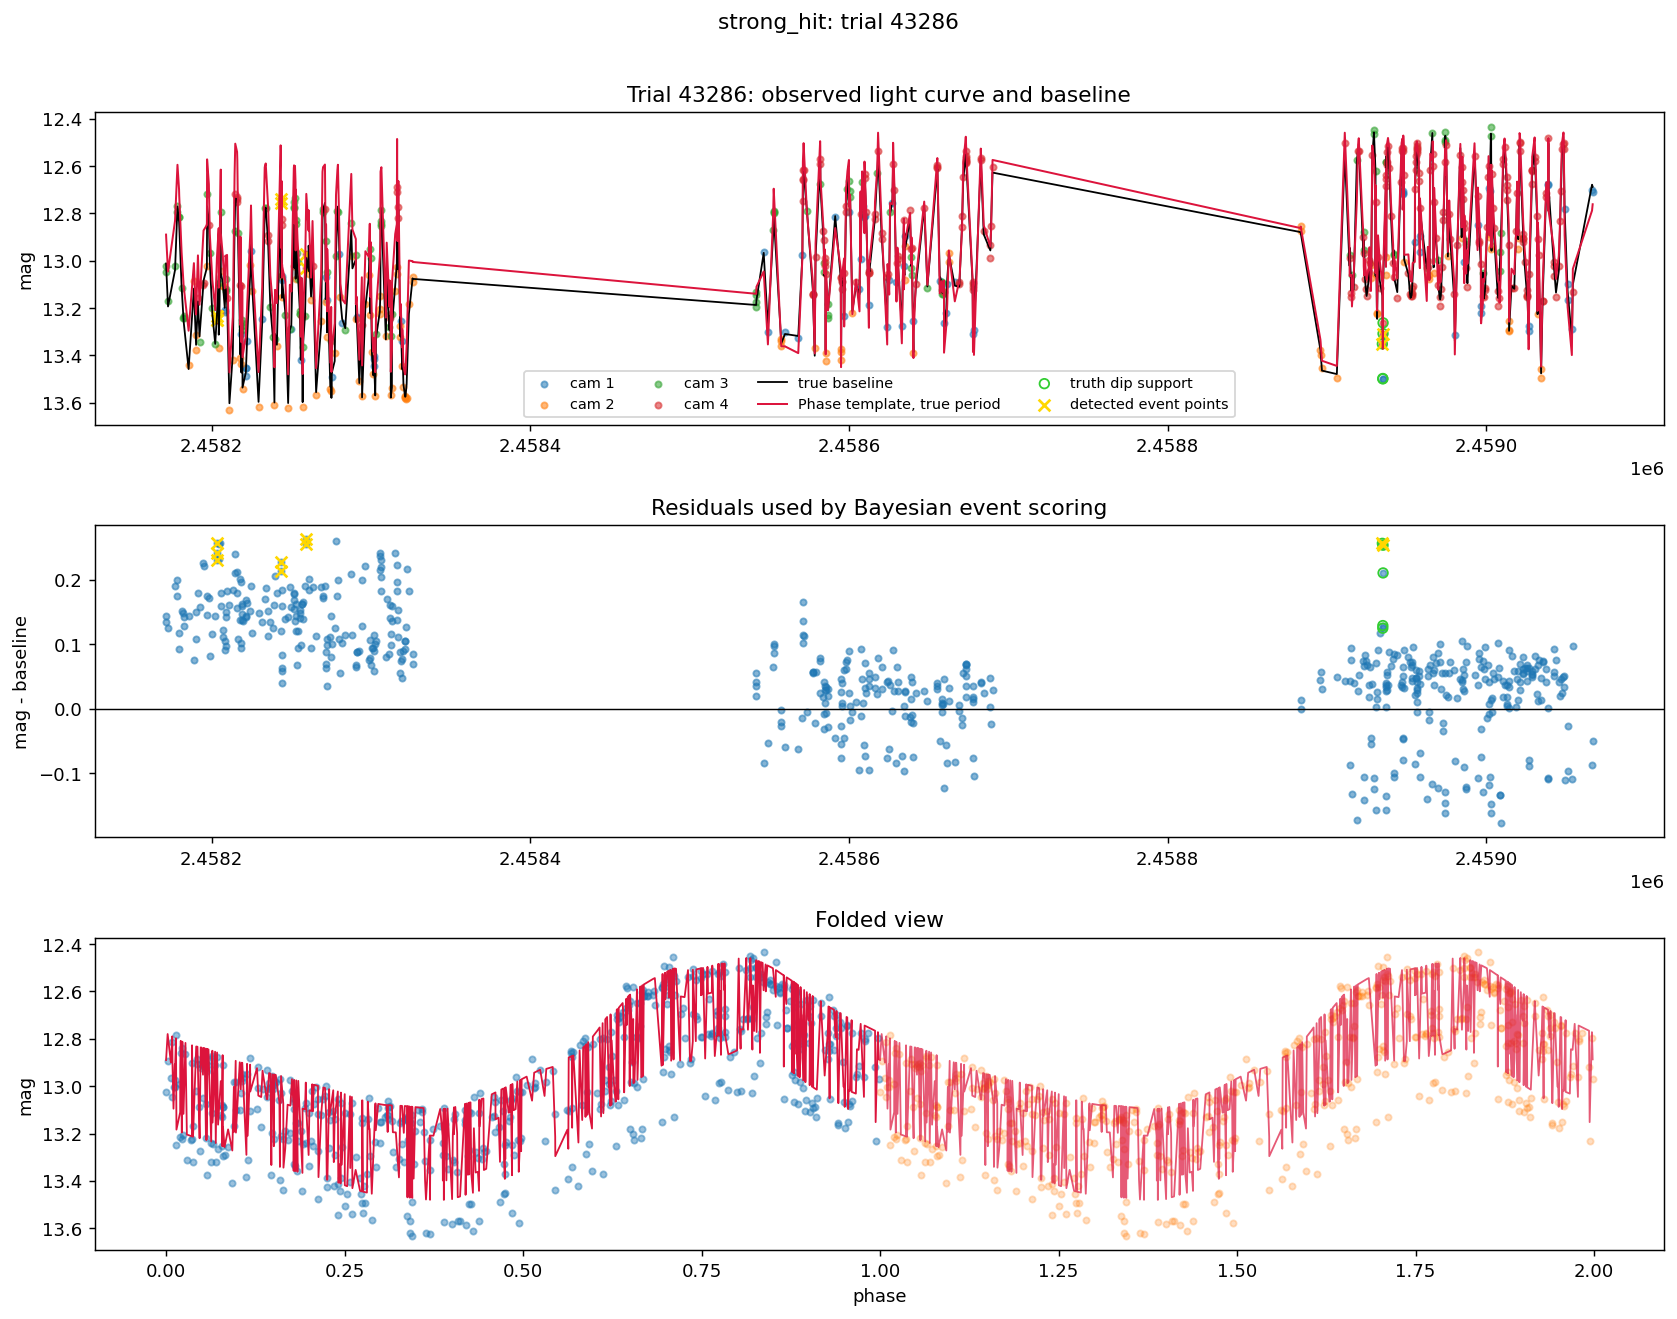

Plotting observable_miss: trial_id=85669, mode=phase_template_true_period


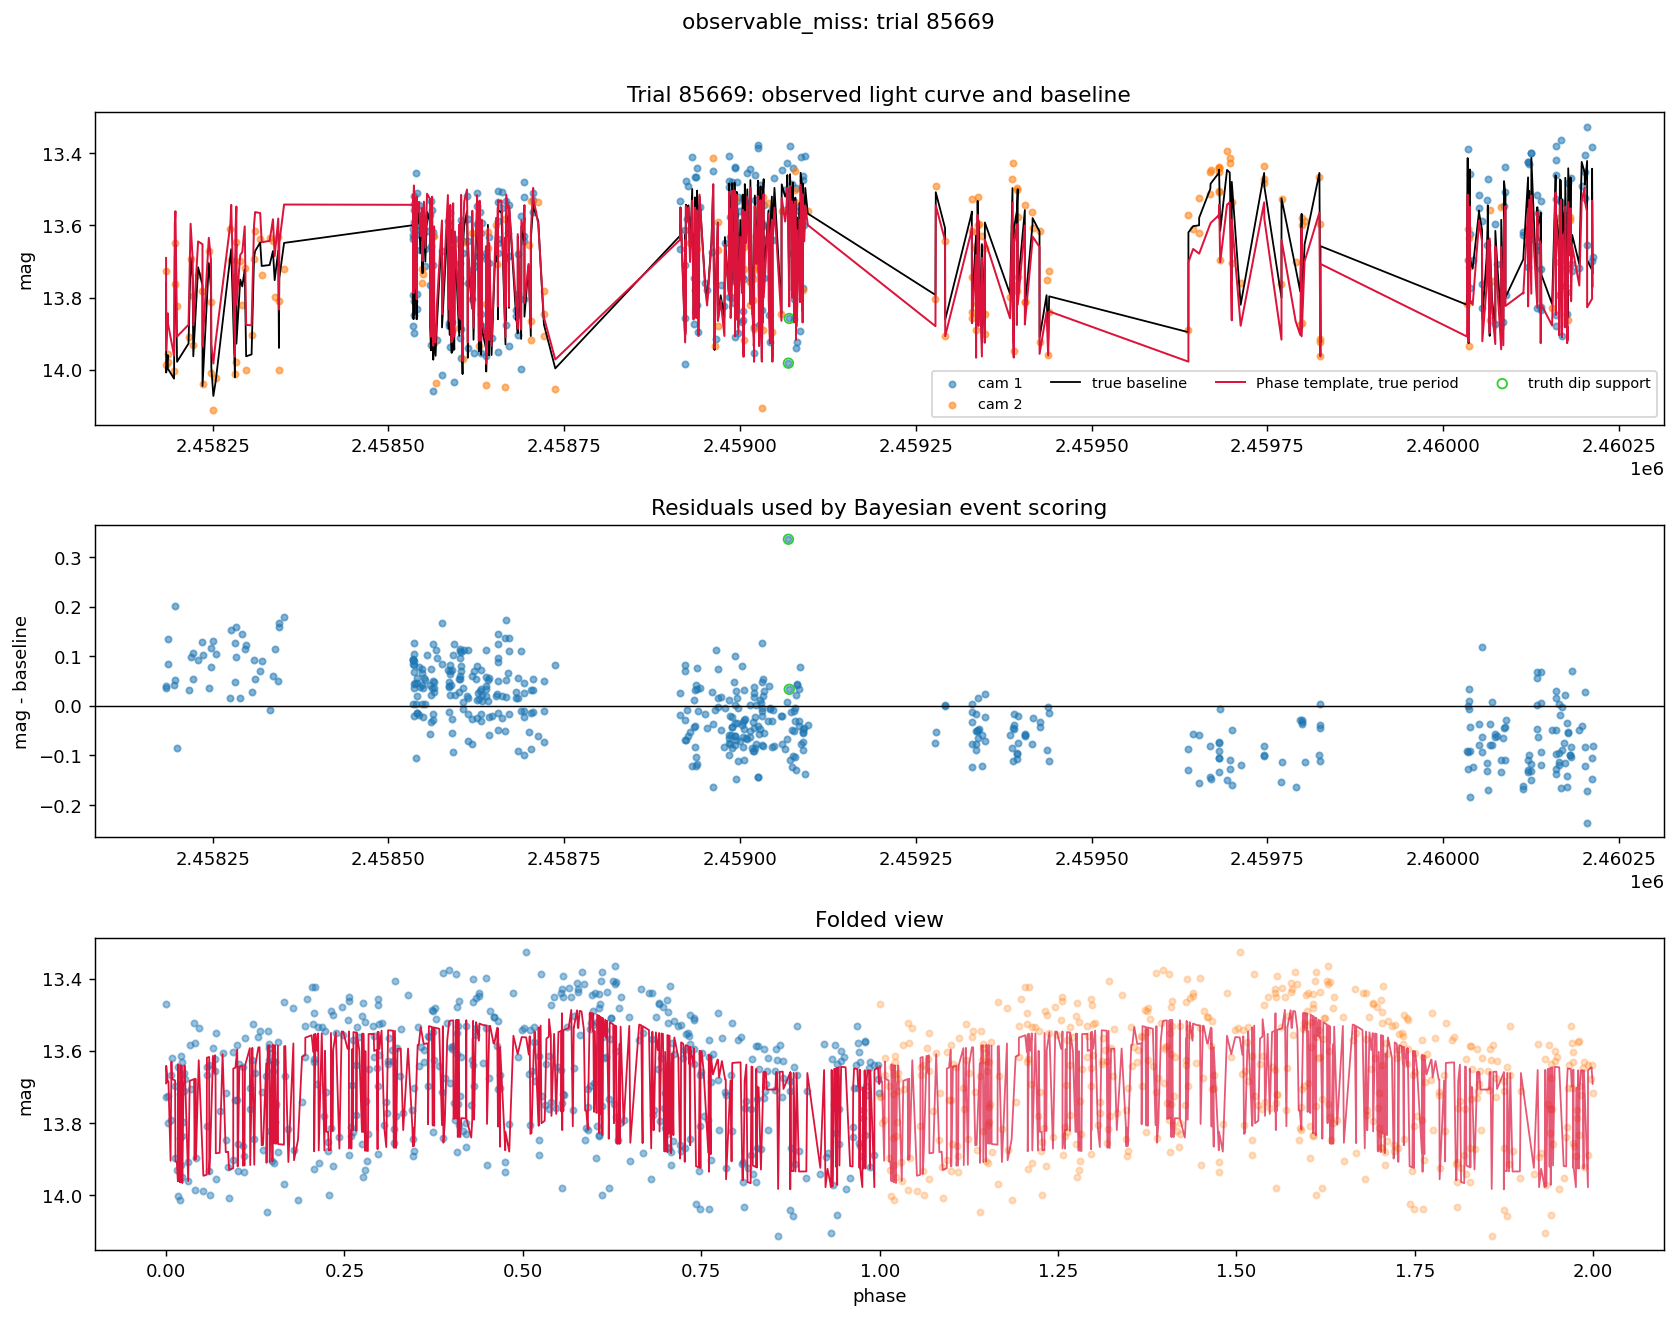

Plotting off_target_detection: trial_id=45546, mode=phase_template_true_period


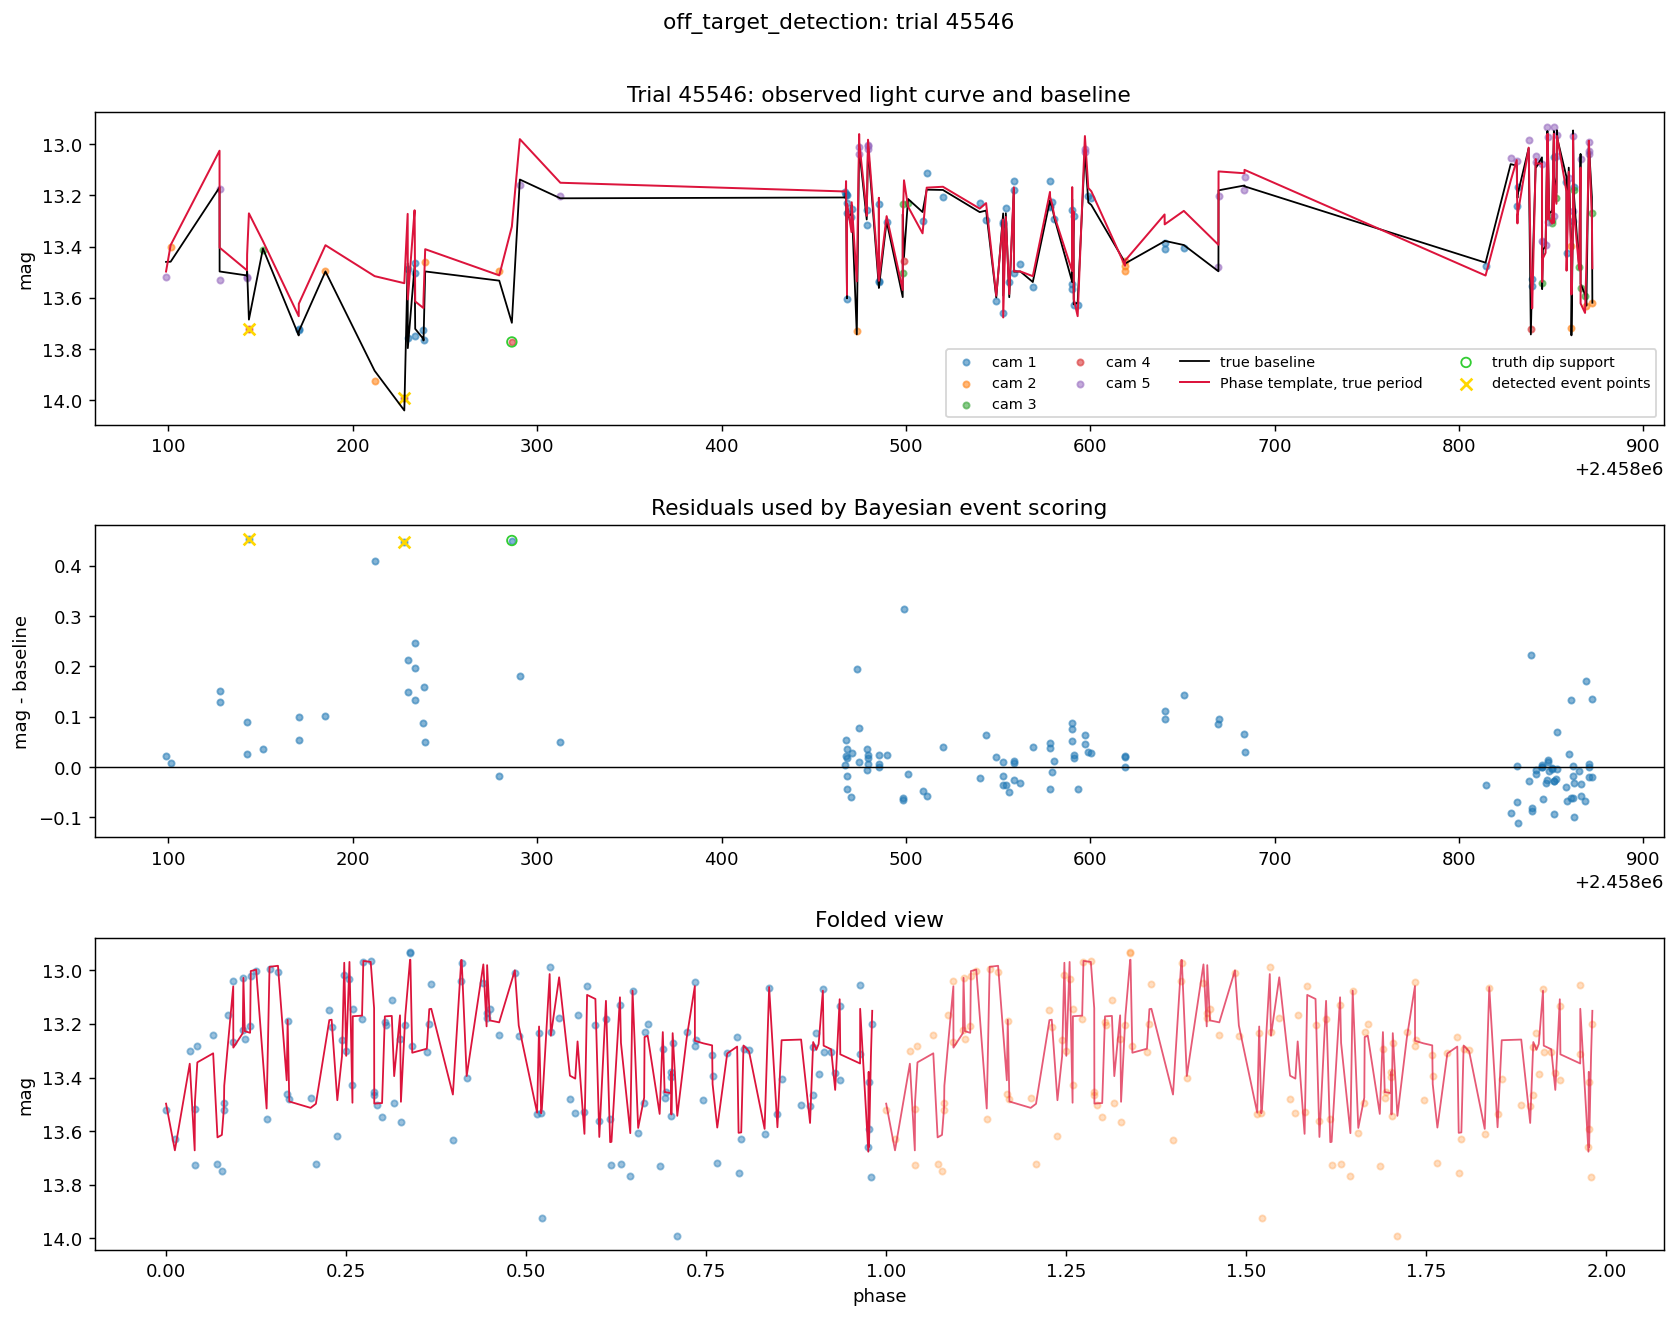

Plotting control_false_positive: trial_id=70853, mode=phase_template_true_period


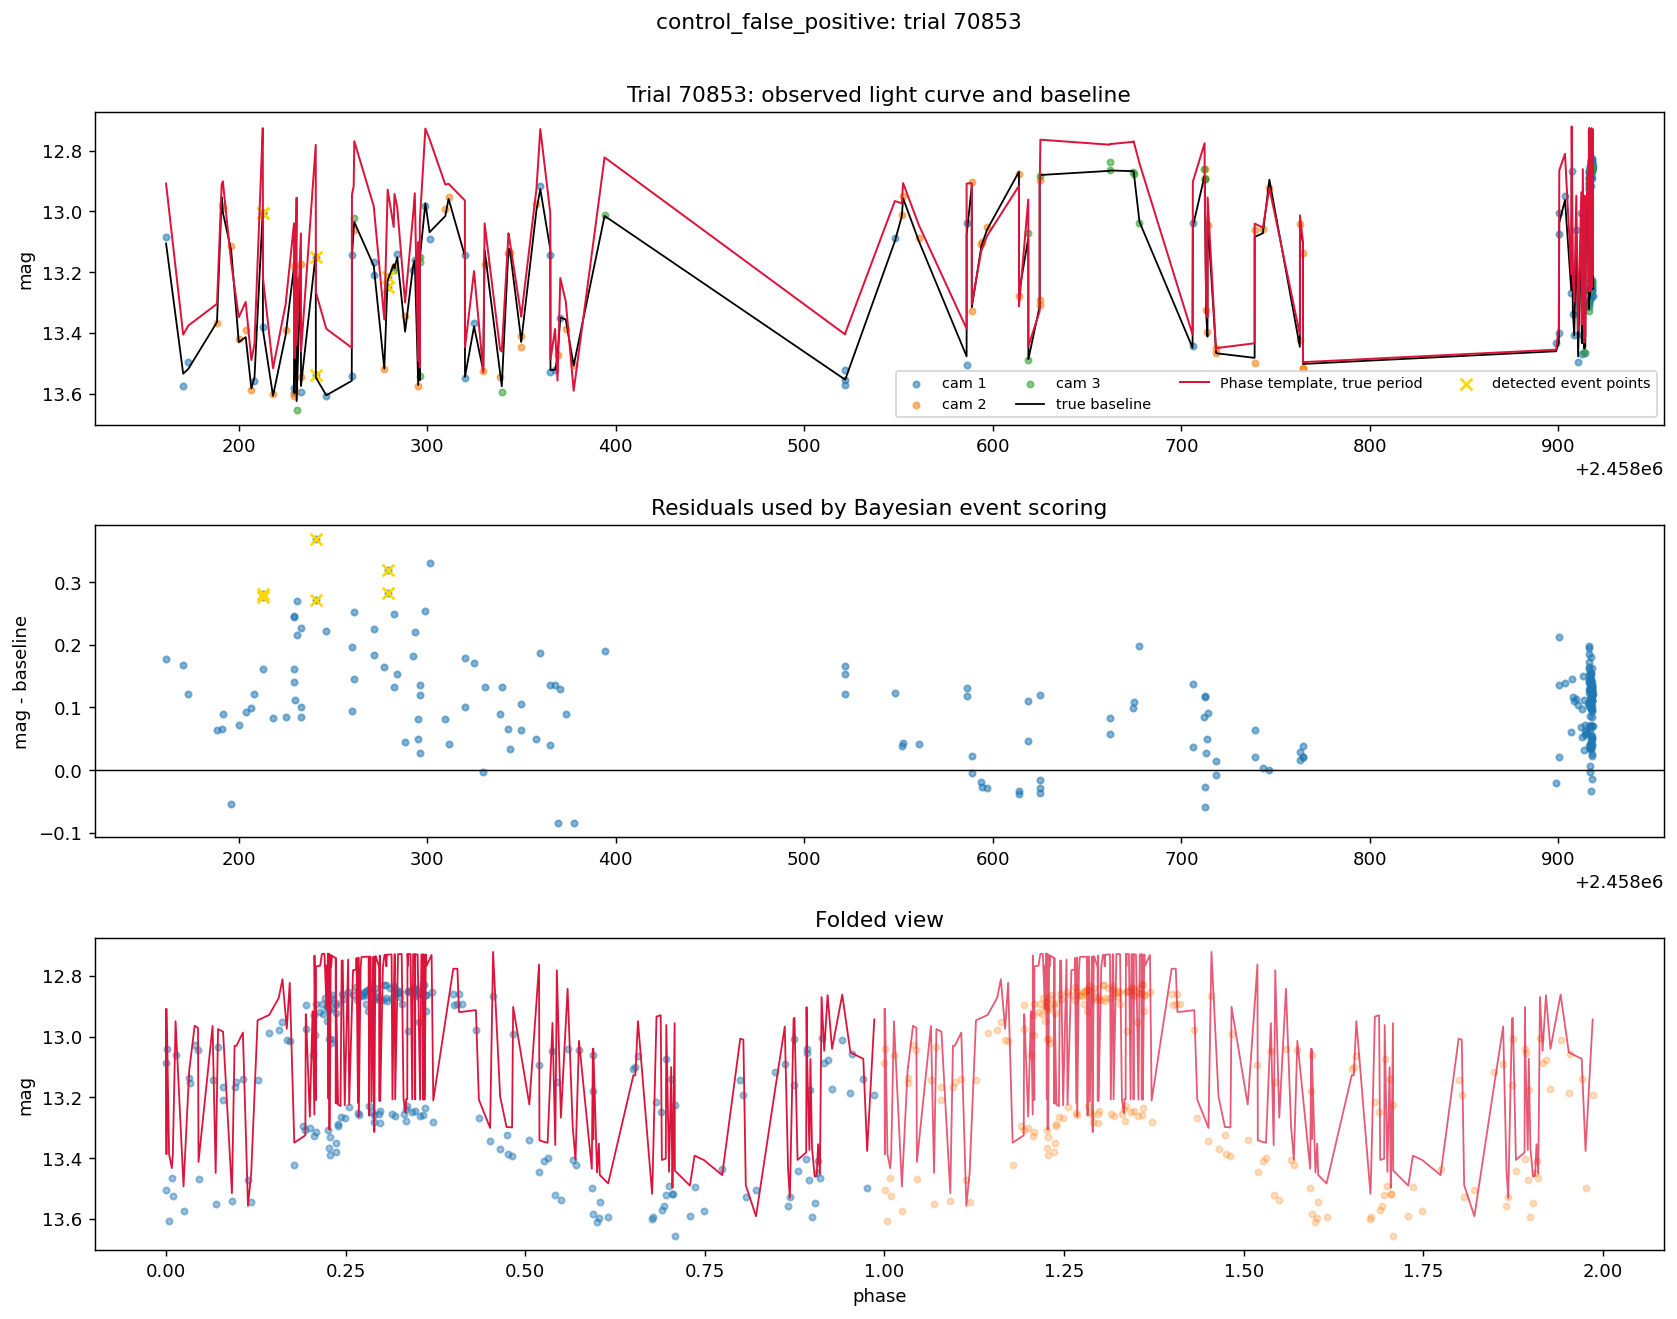

Plotting phase_template_fallback: trial_id=215, mode=phase_template_true_period


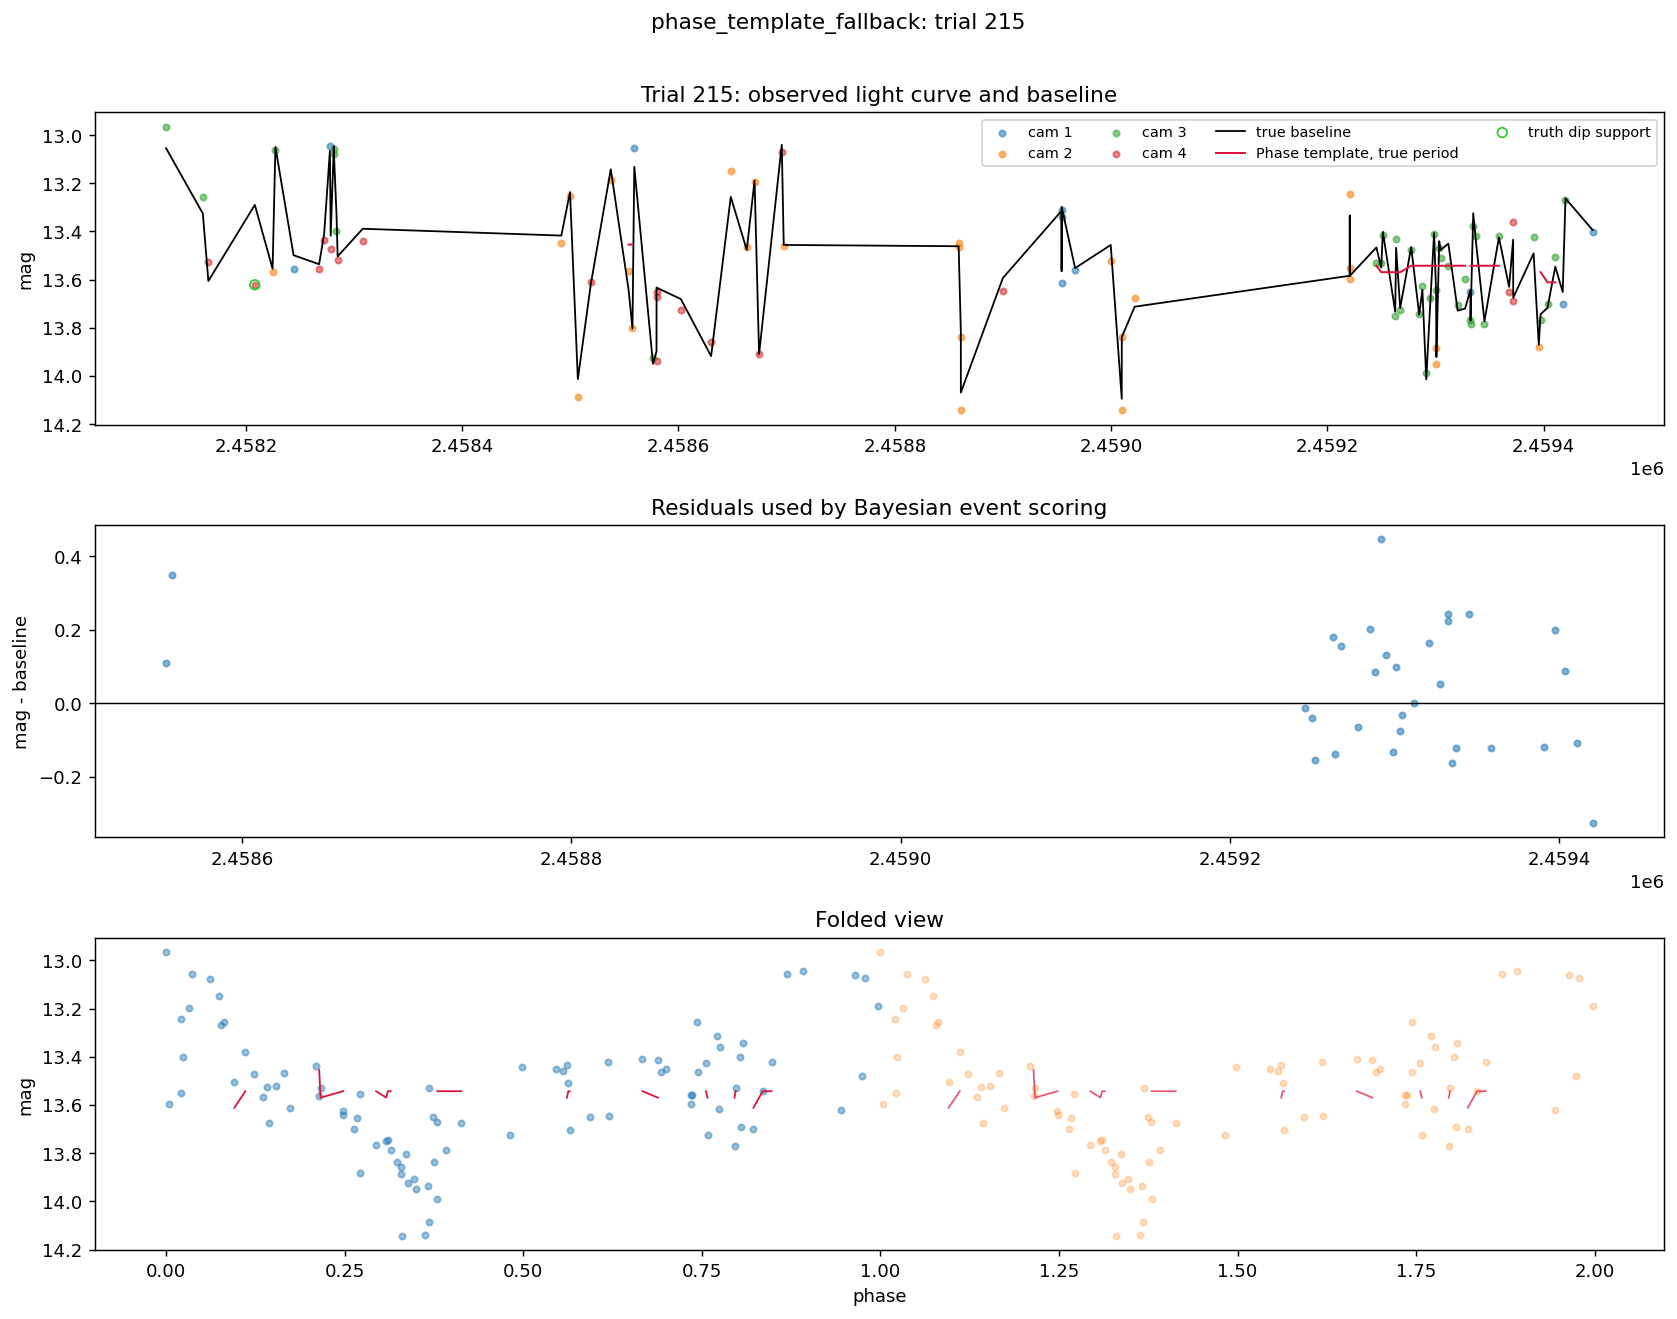

In [14]:
for label, trial_id in examples.items():
    if trial_id is None:
        print(f"No example available for {label}")
        continue
    print(f"Plotting {label}: trial_id={trial_id}, mode={example_mode}")
    axes = plot_trial_diagnostic(run, trial_id, mode=example_mode)
    axes[0].figure.suptitle(f"{label}: trial {trial_id}", y=1.01)
    axes[0].figure.tight_layout()
    axes[0].figure.savefig(plots_dir / f"example_{label}_trial_{trial_id}_{example_mode}.png")
    plt.show()


## Period Selection Sensitivity

The actual periodic branch receives `pre_periodicity_selected_period`, not necessarily the true period. The table below isolates how much recovery and baseline quality degrade as the selected period becomes imperfect.

,mode,n,observable_recall,precision_by_trial,control_false_positive_rate,off_target_detection_rate,median_baseline_mae_outside_dip,median_resid_rms_outside_dip,median_amp_recovery_ratio,phase_template_fallback_rate
1,phase_template_1pct_period_error,119896,0.002067,0.405405,0.003249,0.001882,0.057672,0.104225,1.264971,0.030143
2,phase_template_5pct_period_error,119923,0.001518,0.348837,0.001916,0.001862,0.067670,0.116523,1.300443,0.030103
3,phase_template_true_period,119807,0.005468,0.717863,0.001666,0.001382,0.038151,0.076465,1.162762,0.030416


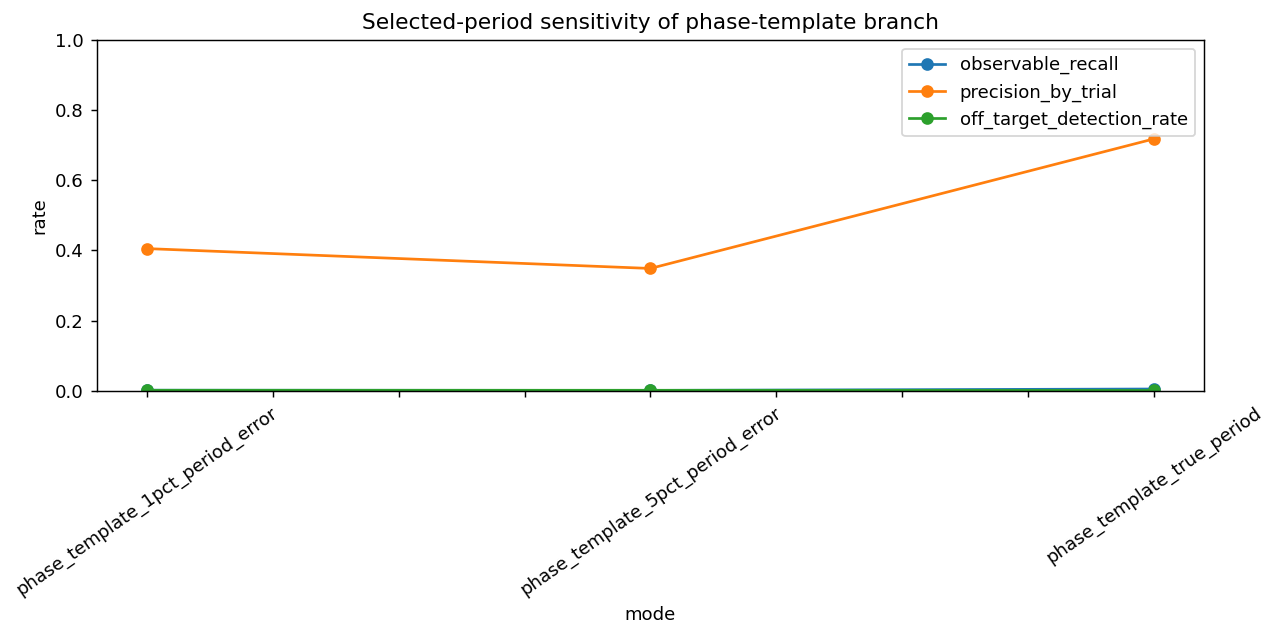

In [15]:
from malca.plotting.lightcurve_publication import (
    figsize_from_legacy,
    finalize_publication_figure,
)
period_modes = [mode for mode in results["mode"].unique() if mode.startswith("phase_template")]
period_sensitivity = (
    run.summary_overall[run.summary_overall["mode"].isin(period_modes)]
    .sort_values("mode")
    [[
        "mode", "n", "observable_recall", "precision_by_trial", "control_false_positive_rate",
        "off_target_detection_rate", "median_baseline_mae_outside_dip", "median_resid_rms_outside_dip",
        "median_amp_recovery_ratio", "phase_template_fallback_rate",
    ]]
)
display(period_sensitivity)

if len(period_modes) > 1:
    fig, ax = plt.subplots(figsize=figsize_from_legacy(10, 5))
    period_sensitivity.set_index("mode")[["observable_recall", "precision_by_trial", "off_target_detection_rate"]].plot(marker="o", ax=ax)
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("rate")
    ax.set_title("Selected-period sensitivity of phase-template branch")
    ax.tick_params(axis="x", rotation=35)
    finalize_publication_figure(fig)
    fig.savefig(plots_dir / "period_selection_sensitivity.png")
    plt.show()


## Error Rows

Failures in this table indicate simulation or production-code edge cases, not missed detections. They should be rare. If they are not rare, inspect `error` first and then the corresponding simulated trial.

In [16]:
error_rows = results[~results["status"].eq("ok")].copy()
print(f"Error rows: {len(error_rows):,} / {len(results):,}")
if not error_rows.empty:
    display(error_rows[["trial_id", "mode", "status", "error"]].head(50))
else:
    print("No scoring errors in this benchmark run.")

Error rows: 6,862 / 480,000


,trial_id,mode,status,error
52,28,gp_masked_control,error,module 'numpy' has no attribute 'trapezoid'
377,46,phase_template_1pct_period_error,error,module 'numpy' has no attribute 'trapezoid'
408,248,gp_masked_control,error,module 'numpy' has no attribute 'trapezoid'
430,111,gp_masked_control,error,module 'numpy' has no attribute 'trapezoid'
469,126,gp_masked_control,error,module 'numpy' has no attribute 'trapezoid'
488,244,gp_masked_control,error,module 'numpy' has no attribute 'trapezoid'
628,118,gp_masked_control,error,module 'numpy' has no attribute 'trapezoid'
647,236,gp_masked_control,error,module 'numpy' has no attribute 'trapezoid'
686,234,gp_masked_control,error,module 'numpy' has no attribute 'trapezoid'
705,267,gp_masked_control,error,module 'numpy' has no attribute 'trapezoid'


## Interpretation Checklist

Use this checklist after the run finishes:

- If `phase_template_true_period` has low `observable_recall`, the phase-template residual branch itself is failing on simulated one-off dips.
- If true-period recall is good but 1% or 5% period-error recall collapses, the branch is mostly period-selection limited.
- If `phase_template_true_period` has high `off_target_detection_rate`, the periodic template is leaving structured residuals that trigger false events.
- If `control_false_positive_rate` is high, the phase-template residual baseline is manufacturing dip-like residuals even without injected dips.
- If `median_amp_recovery_ratio` is far below one, the phase-template baseline is absorbing part of one-off dips.
- If the GP control beats phase-template on periodic baselines, inspect whether the simulated periods are too long/sparse for folding or whether the phase template is under-smoothed/over-smoothed.

The most useful next notebook pass is usually to filter `misses` or `control_fp` by one failure mode, plot 10 to 20 examples, and then adjust either the periodic pre-gate period-quality requirements or the phase-template baseline settings.